# Notebook 2.5 — Measurement-specific theoretical gamma flux

This notebook is the gamma-transport counterpart to Notebook 2. It imports the
shared OpenMC geometry and materials from `ambe_base_model.py` and calculates
the theoretical photon flux at the 61 measurement-specific P1–P5 scan
positions.

The source energy distribution consists of the prompt Am–Be gamma lines
returned by ALPHANSO. OpenMC is normalized per emitted source photon. The
per-source tallies are converted to physical gamma flux using

$$
S_\gamma(t)
=
\frac{Y_\gamma}{Y_n}S_n(t),
$$

where $Y_\gamma/Y_n$ is the ALPHANSO total gamma-to-neutron yield ratio and
$S_n(t)$ is the source-specific neutron emission decay-corrected from the
factory reference date to 15 March 2026.

The physical source is the Amersham AMN 24 source with serial number
`AMN 5000/1365`. Its factory neutron emission was
$1.20\times10^7\ \mathrm{n\,s^{-1}}$ on 5 July 1968. The factory report does
not provide a photon yield or an uncertainty for the neutron-emission result.
Consequently, the absolute gamma normalization is model-based and its total
uncertainty is not known.

The measurement-specific tally volume is based on the active region of the
LND 712 Geiger–Mueller tube used in the GCA-07W-DL external wand. It is modeled
as an exact finite right circular CSG cylinder with the documented effective
diameter and length of the LND 712. A `CellFilter` scores photon flux in each
air-filled detector volume. This calculates incident photon flux averaged over
a detector-shaped volume; it does **not** simulate the energy-dependent CPS
response of the Geiger counter.

The 61 alternative detector placements are divided automatically into two
non-overlapping transport groups. Group 1 contains 60 placements and uses
photon weight windows generated with OpenMC's MAGIC method. Its production run
uses tally triggers and stops automatically when every scalar group-1 flux
tally reaches a relative Monte Carlo standard uncertainty of at most 10%, or
when a documented safety limit on the number of batches is reached. Group 2
contains the remaining overlapping P1 placement and reuses the existing analog
statepoint.

This notebook contains gamma-flux simulation only. It does not process the
digital Geiger-counter measurements and does not convert gamma flux to dose
rate. Those operations belong in later notebooks.


# 1) Setup and shared base geometry

The shared model is loaded without editing or patching
`ambe_base_model.py`. The experiment date is passed to the shared source
record so that Notebook 2 and Notebook 2.5 use the same physical
normalization date.

Section 4 creates a fresh copy of the shared model for each non-overlapping
transport group. The detector scoring cells are filled with the same air
material as the surrounding outside-air cell. They therefore introduce only
internal scoring boundaries and do not change the material transport model.
The corresponding detector regions are subtracted from the outside-air cell
before the scoring cells are added, so each transport geometry remains a
valid, non-overlapping CSG partition.


In [54]:
from pathlib import Path
import importlib
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

import openmc
import ambe_base_model


# Reload after deliberate edits to the shared module.
importlib.reload(ambe_base_model)


# ------------------------------------------------------------
# Physical normalization date
# ------------------------------------------------------------

EXPERIMENT_DATE = "2026-03-15"


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

OUTPUT_DIR = Path("N2_5_simulated_gamma_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Load the common geometry, materials and source record
# ------------------------------------------------------------

base = ambe_base_model.build_base_model(
    export_xml=False,
    verbose=True,
    source_evaluation_date=EXPERIMENT_DATE,
)

globals().update(base)

required_base_names = [
    "geometry",
    "materials",
    "root",
    "outside_air_cell",
    "air",
    "CABINET_XMAX",
    "CABINET_YMIN",
    "CABINET_YMAX",
    "CABINET_ZMIN",
    "SOURCE_MANUFACTURER",
    "SOURCE_MODEL",
    "SOURCE_SERIAL_NUMBER",
    "SOURCE_NEUTRON_EMISSION_REF",
    "SOURCE_NEUTRON_EMISSION_REF_DATE",
    "SOURCE_NEUTRON_EMISSION",
    "SOURCE_EVALUATION_DATE",
    "SOURCE_NORMALIZATION_STATUS",
]

missing_base_names = [
    name for name in required_base_names
    if name not in globals()
]

if missing_base_names:
    raise NameError(
        "The shared base model is missing: "
        + ", ".join(missing_base_names)
    )

if SOURCE_EVALUATION_DATE != EXPERIMENT_DATE:
    raise ValueError(
        "The shared model did not use the selected experiment date. "
        f"Expected {EXPERIMENT_DATE}, got {SOURCE_EVALUATION_DATE}."
    )

print()
print("Shared base geometry loaded into Notebook 2.5.")
print(f"Physical source:             {SOURCE_MODEL}, {SOURCE_SERIAL_NUMBER}")
print(
    "Factory neutron emission:   "
    f"{SOURCE_NEUTRON_EMISSION_REF:.3e} n/s on "
    f"{SOURCE_NEUTRON_EMISSION_REF_DATE}"
)
print(
    "Selected neutron emission:  "
    f"{SOURCE_NEUTRON_EMISSION:.6e} n/s on "
    f"{SOURCE_EVALUATION_DATE}"
)
print(f"Normalization status:        {SOURCE_NORMALIZATION_STATUS}")
print(f"Output folder:               {OUTPUT_DIR}")


Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           = 0.955 cm
  Source active radius          = 0.675 cm
  Source active height          = 4.300 cm

Materials and geometry built.
Defined cells:
  230: Cabinet wall
  231: Cabinet inner air
  232: Inner paraffin block around source
  233: Outer paraffin moderator
  234: 

# 2) ALPHANSO gamma-line source and physical scaling

The shared gamma-line builder must already exist in
`ambe_base_model.py`. This notebook does not inject code into that module.

ALPHANSO supplies both the discrete gamma-line distribution and model yields.
The line probabilities are normalized to one source photon for OpenMC. The
absolute photon rate is calculated separately from the ratio of the total
ALPHANSO gamma and neutron yields:

$$
\frac{S_\gamma}{S_n}=\frac{Y_\gamma}{Y_n}.
$$

This ratio is an ALPHANSO model result based on the adopted Am–Be mixture
approximation. It is not a source-specific photon-yield measurement from the
AMN 5000/1365 factory certificate.

Am-Be gamma emission lines:
  Total gamma yield: 2.783366e+06
  E = 3.2138 MeV, yield = 1.559798e+02, probability = 0.005604 %
  E = 4.4389 MeV, yield = 2.783210e+06, probability = 99.994396 %

Dominant gamma line:
  E = 4.4389 MeV
  probability = 99.994396 %


,E_gamma [MeV],line_yield,relative_probability,relative_probability [%]
0,3.2138,1.559798e+02,0.000056,0.005604
1,4.4389,2.783210e+06,0.999944,99.994396



Gamma source scaling:
  ALPHANSO neutron yield (an_yield): 4.268302e+06
  ALPHANSO gamma yield:              2.783366e+06
  ALPHANSO gamma/neutron ratio:      0.652101 photons/neutron
  Physical neutron source:           1.094044e+07 n/s
  Estimated physical gamma source:   7.134276e+06 photons/s


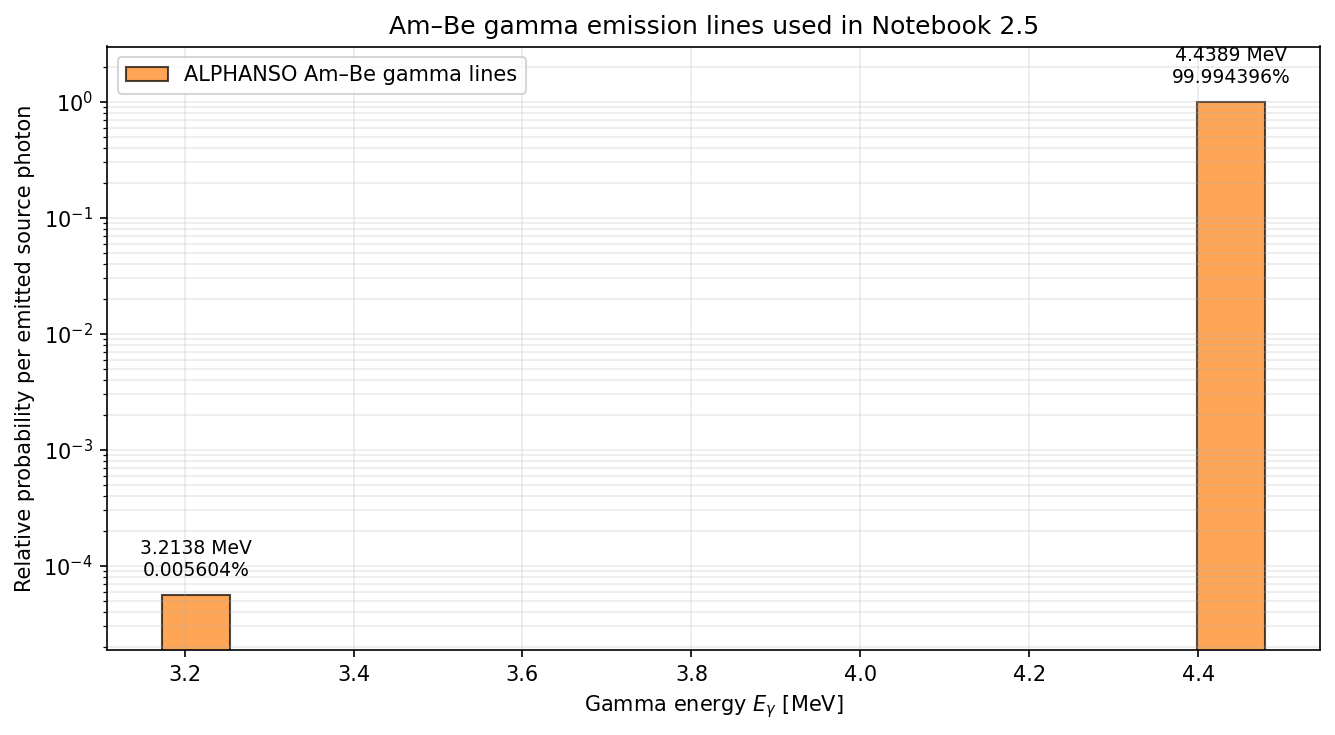

Saved gamma-line table:  N2_5_simulated_gamma_outputs/tables/ambe_gamma_lines_used_in_notebook_2_5.csv
Saved gamma-line figure: N2_5_simulated_gamma_outputs/figures/section_2_ambe_gamma_emission_lines.png


In [55]:
if not hasattr(ambe_base_model, "build_ambe_gamma_line_distribution"):
    raise AttributeError(
        "ambe_base_model.py does not contain "
        "build_ambe_gamma_line_distribution(). Update the shared module "
        "before running Notebook 2.5."
    )


gamma_energy_dist, gamma_data = (
    ambe_base_model.build_ambe_gamma_line_distribution(
        make_plot=False,
        verbose=True,
    )
)

gamma_energies_mev = np.asarray(
    gamma_data["gamma_energies_mev"],
    dtype=float,
)
gamma_line_yields = np.asarray(
    gamma_data["gamma_line_yields"],
    dtype=float,
)
gamma_prob = np.asarray(
    gamma_data["gamma_prob"],
    dtype=float,
)

if not (
    gamma_energies_mev.ndim == 1
    and gamma_line_yields.shape == gamma_energies_mev.shape
    and gamma_prob.shape == gamma_energies_mev.shape
    and gamma_energies_mev.size > 0
):
    raise ValueError("The ALPHANSO gamma-line arrays are inconsistent.")

if not np.all(np.isfinite(gamma_energies_mev)):
    raise ValueError("Gamma-line energies contain non-finite values.")

if not np.all(np.isfinite(gamma_line_yields)):
    raise ValueError("Gamma-line yields contain non-finite values.")

if not np.all(np.isfinite(gamma_prob)) or np.any(gamma_prob < 0.0):
    raise ValueError("Gamma-line probabilities are invalid.")

if not np.isclose(gamma_prob.sum(), 1.0, rtol=1.0e-10, atol=1.0e-12):
    raise ValueError(
        "Gamma-line probabilities are not normalized to one. "
        f"Found sum = {gamma_prob.sum():.12g}."
    )


alphanso_results = gamma_data.get("alphanso_results")

if not isinstance(alphanso_results, dict):
    raise RuntimeError(
        "ALPHANSO results are unavailable. A fallback line spectrum is "
        "not sufficient for the final physical gamma normalization."
    )

if "an_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["an_yield"])
    alphanso_neutron_yield_key = "an_yield"
elif "combined_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["combined_yield"])
    alphanso_neutron_yield_key = "combined_yield"
else:
    raise KeyError(
        "ALPHANSO results contain neither 'an_yield' nor "
        "'combined_yield'."
    )

alphanso_gamma_yield = float(gamma_data["gamma_yield"])

for name, value in [
    ("ALPHANSO neutron yield", alphanso_neutron_yield),
    ("ALPHANSO gamma yield", alphanso_gamma_yield),
]:
    if not np.isfinite(value) or value <= 0.0:
        raise ValueError(f"{name} must be finite and positive; got {value}.")


GAMMA_TO_NEUTRON_RATIO_ALPHANSO = (
    alphanso_gamma_yield / alphanso_neutron_yield
)

GAMMA_SOURCE_EMISSION = (
    GAMMA_TO_NEUTRON_RATIO_ALPHANSO
    * SOURCE_NEUTRON_EMISSION
)

# Alias retained for compatibility with shared-model metadata conventions.
SOURCE_GAMMA_EMISSION = GAMMA_SOURCE_EMISSION

GAMMA_SOURCE_NORMALIZATION_STATUS = (
    "decay-corrected source-specific neutron emission multiplied by the "
    "ALPHANSO total gamma-to-neutron yield ratio"
)


gamma_lines_df = pd.DataFrame({
    "E_gamma [MeV]": gamma_energies_mev,
    "line_yield": gamma_line_yields,
    "relative_probability": gamma_prob,
    "relative_probability [%]": 100.0 * gamma_prob,
})

gamma_lines_csv = TABLE_DIR / "ambe_gamma_lines_used_in_notebook_2_5.csv"
gamma_lines_df.to_csv(gamma_lines_csv, index=False)

display(gamma_lines_df)

print()
print("Gamma source scaling:")
print(
    f"  ALPHANSO neutron yield ({alphanso_neutron_yield_key}): "
    f"{alphanso_neutron_yield:.6e}"
)
print(f"  ALPHANSO gamma yield:              {alphanso_gamma_yield:.6e}")
print(
    "  ALPHANSO gamma/neutron ratio:      "
    f"{GAMMA_TO_NEUTRON_RATIO_ALPHANSO:.6f} photons/neutron"
)
print(f"  Physical neutron source:           {SOURCE_NEUTRON_EMISSION:.6e} n/s")
print(f"  Estimated physical gamma source:   {GAMMA_SOURCE_EMISSION:.6e} photons/s")


# ------------------------------------------------------------
# Save the source-line figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

ax.bar(
    gamma_energies_mev,
    gamma_prob,
    width=0.08,
    align="center",
    alpha=0.70,
    color="tab:orange",
    edgecolor="black",
    label="ALPHANSO Am–Be gamma lines",
)

for energy, probability in zip(gamma_energies_mev, gamma_prob):
    ax.text(
        energy,
        probability * 1.35,
        f"{energy:.4f} MeV\n{100.0 * probability:.6f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

positive_probabilities = gamma_prob[gamma_prob > 0.0]
ax.set_ylim(
    positive_probabilities.min() / 3.0,
    positive_probabilities.max() * 3.0,
)
ax.set_yscale("log")
ax.set_xlabel(r"Gamma energy $E_\gamma$ [MeV]")
ax.set_ylabel("Relative probability per emitted source photon")
ax.set_title("Am–Be gamma emission lines used in Notebook 2.5")
ax.grid(True, which="both", alpha=0.25)
ax.legend()

fig.tight_layout()

gamma_lines_figure_path = (
    FIGURE_DIR / "section_2_ambe_gamma_emission_lines.png"
)
fig.savefig(gamma_lines_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved gamma-line table:  {gamma_lines_csv}")
print(f"Saved gamma-line figure: {gamma_lines_figure_path}")


# ------------------------------------------------------------
# Photon-source and fixed-source settings helpers
# ------------------------------------------------------------

def build_gamma_source(gamma_energy_distribution, source_strength=1.0):
    """Build an isotropic point photon source at the capsule centre."""

    source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        angle=openmc.stats.Isotropic(),
        energy=gamma_energy_distribution,
        particle="photon",
    )
    source.strength = float(source_strength)
    return source


def build_gamma_settings(
    gamma_energy_distribution,
    batches,
    particles,
    inactive=0,
    source_strength=1.0,
    seed=20260315,
):
    """Build fixed-source OpenMC settings for photon transport."""

    settings = openmc.Settings()
    settings.run_mode = "fixed source"
    settings.source = build_gamma_source(
        gamma_energy_distribution=gamma_energy_distribution,
        source_strength=source_strength,
    )
    settings.batches = int(batches)
    settings.particles = int(particles)
    settings.inactive = int(inactive)
    settings.seed = int(seed)
    settings.photon_transport = True

    return settings

# 3) Measurement-specific P1–P5 gamma scan points and LND 712 geometry

The GCA-07W-DL operation manual states that the instrument uses an external
wand containing a neon-plus-halogen Geiger–Mueller tube. The manual specifies
a mica end window with an effective diameter of $0.38''$ and an areal density
of $1.5$–$2.0\ \mathrm{mg\,cm^{-2}}$ (pp. 3–4 and 31). The current Images SI
product page identifies the tube in the GCA-07W-DL as an LND 712.

The LND 712 manufacturer specification gives the dimensions of the effective
region as

$$
d_\mathrm{eff}=9.1\ \mathrm{mm}=0.91\ \mathrm{cm},
\qquad
L_\mathrm{eff}=38.1\ \mathrm{mm}=3.81\ \mathrm{cm}.
$$

The sensitive region is therefore approximated by a right circular cylinder:

$$
V_\mathrm{LND712}
=
\pi\left(\frac{d_\mathrm{eff}}{2}\right)^2L_\mathrm{eff}
=
2.478\ \mathrm{cm^3}.
$$

The GCA manual's $0.38''$ window value is a rounded instrument-level value;
the tube-manufacturer value $0.36''=9.1\ \mathrm{mm}$ is used for the active
cylinder.

Sources:

- [Images SI, GCA-07W-DL Operation Manual](https://www.imagesco.com/geiger/pdf/GCA-07W-DL.pdf), pp. 3–4 and 31;
- [Images SI, GCA-07W-DL product page](https://www.imagesco.com/geiger/digital-geiger-counter-dl.html);
- [LND, Model 712 manufacturer specification](https://www.lndinc.com/products/geiger-mueller-tubes/712/).

The code below uses the following explicit experimental convention:

1. `distance_cm` is interpreted as the gap from the cabinet surface to the
   mica-window plane;
2. the mica window faces the cabinet, so the active-cylinder axis is radial and
   points away from the cabinet;
3. the active-volume reference point is the cylinder centre, located
   $L_\mathrm{eff}/2=1.905\ \mathrm{cm}$ behind the mica window.

If the recorded distance was measured to the outer wand housing rather than to
the mica window, `MEASUREMENT_REFERENCE_TO_MICA_CM` must be replaced by the
measured housing-to-window distance. If the wand was side-on or vertical during
the experiment, the axis vectors must likewise be changed to match the actual
setup. The manual does not determine either of those experimental details.

Heights are measured from the cabinet bottom and converted to OpenMC
$z$ coordinates with the shared geometry helper.

In [56]:
def z_from_height(height_cm):
    """Convert height above the cabinet bottom to OpenMC z-coordinate."""

    return ambe_base_model.z_from_cabinet_bottom(
        h_cm=height_cm,
        cabinet_zmin=CABINET_ZMIN,
    )


def normalized_vector(vector):
    """Return a finite, three-component unit vector."""

    vector = np.asarray(vector, dtype=float)

    if vector.shape != (3,) or not np.all(np.isfinite(vector)):
        raise ValueError(f"Invalid direction vector: {vector}")

    norm = np.linalg.norm(vector)

    if norm <= 0.0:
        raise ValueError("A detector-axis vector cannot have zero length.")

    return vector / norm


def make_gamma_point_name(position, distance_cm, height_cm):
    return f"{position}_x{int(distance_cm)}_h{int(height_cm)}"


def add_gamma_scan_point(
    scan_dictionary,
    position,
    distance_cm,
    height_cm,
    cabinet_surface_point,
    outward_unit_vector,
):
    """Add one detector-specific LND 712 active-volume reference point."""

    point_name = make_gamma_point_name(
        position,
        distance_cm,
        height_cm,
    )

    if point_name in scan_dictionary:
        raise KeyError(f"Duplicate gamma scan point: {point_name}")

    surface_point = np.asarray(cabinet_surface_point, dtype=float)
    outward = normalized_vector(outward_unit_vector)

    mica_window_center = (
        surface_point
        + (
            float(distance_cm)
            + MEASUREMENT_REFERENCE_TO_MICA_CM
        ) * outward
    )

    active_center = (
        mica_window_center
        + 0.5 * LND712_EFFECTIVE_LENGTH_CM * outward
    )

    scan_dictionary[point_name] = {
        "position": position,
        "distance_cm": float(distance_cm),
        "height_cm": float(height_cm),
        "center": tuple(float(value) for value in active_center),
        "mica_window_center": tuple(
            float(value) for value in mica_window_center
        ),
        "axis_unit_vector": tuple(float(value) for value in outward),
    }


# ------------------------------------------------------------
# Documented GCA-07W-DL / LND 712 dimensions
# ------------------------------------------------------------

GCA_MANUAL_WINDOW_DIAMETER_CM = 0.38 * 2.54
GCA_MANUAL_WINDOW_AREAL_DENSITY_MG_CM2 = (1.5, 2.0)

LND712_EFFECTIVE_DIAMETER_CM = 0.91
LND712_EFFECTIVE_RADIUS_CM = LND712_EFFECTIVE_DIAMETER_CM / 2.0
LND712_EFFECTIVE_LENGTH_CM = 3.81
LND712_MAXIMUM_DIAMETER_CM = 1.51
LND712_MAXIMUM_LENGTH_CM = 4.92

LND712_ACTIVE_VOLUME_CM3 = (
    np.pi
    * LND712_EFFECTIVE_RADIUS_CM**2
    * LND712_EFFECTIVE_LENGTH_CM
)

# Experimental distance convention used in this notebook.
# A nonzero value is required only if the recorded reference surface was
# separated from the mica-window plane. It must then be measured physically.
MEASUREMENT_REFERENCE_TO_MICA_CM = 0.0

GAMMA_REFERENCE_OFFSET_CM = (
    MEASUREMENT_REFERENCE_TO_MICA_CM
    + 0.5 * LND712_EFFECTIVE_LENGTH_CM
)

GAMMA_DETECTOR_ORIENTATION = (
    "end-on: mica window faces the cabinet; active axis is radial"
)

GAMMA_DISTANCE_REFERENCE = (
    "distance_cm is the cabinet-surface-to-mica-window gap"
)


P1_MEASUREMENTS = [
    (0, 42), (0, 85),
    (4, 42), (4, 85),
    (7, 85),
    (57, 42), (57, 85),
    (114, 42), (114, 85),
    (176, 42), (176, 85),
    (199, 42), (199, 85),
    (320, 42), (320, 85),
    (420, 42), (420, 85),
]

P2_MEASUREMENTS = [
    (0, 85),
    (2, 55),
    (5, 85),
    (30, 85),
    (57, 55), (57, 85),
    (114, 55), (114, 85),
    (156, 85),
    (176, 55), (176, 85),
    (199, 55), (199, 85),
    (300, 85),
    (321, 55), (321, 85),
    (420, 55),
]

P3_MEASUREMENTS = [
    (0, 45), (0, 85),
    (5, 45), (5, 85),
    (57, 45), (57, 85),
    (100, 85),
    (114, 45), (114, 85),
    (176, 45), (176, 85),
    (199, 45),
    (200, 85),
    (225, 45), (225, 85),
    (300, 45), (300, 85),
    (400, 85),
]

P4_MEASUREMENTS = [
    (0, 42),
    (20, 42),
    (71, 42),
    (85, 45),
    (152, 113),
]

P5_MEASUREMENTS = [
    (0, 45),
    (0, 85),
    (6, 45),
    (6, 85),
]


MEASUREMENTS_BY_POSITION = {
    "P1": P1_MEASUREMENTS,
    "P2": P2_MEASUREMENTS,
    "P3": P3_MEASUREMENTS,
    "P4": P4_MEASUREMENTS,
    "P5": P5_MEASUREMENTS,
}

CABINET_SURFACE_XY_BY_POSITION = {
    "P1": (0.0, CABINET_YMIN),
    "P2": (CABINET_XMAX, CABINET_YMIN),
    "P3": (CABINET_XMAX, 0.0),
    "P4": (CABINET_XMAX, CABINET_YMAX),
    "P5": (0.0, CABINET_YMAX),
}

OUTWARD_UNIT_VECTOR_BY_POSITION = {
    "P1": normalized_vector((0.0, -1.0, 0.0)),
    "P2": normalized_vector((1.0, -1.0, 0.0)),
    "P3": normalized_vector((1.0, 0.0, 0.0)),
    "P4": normalized_vector((1.0, 1.0, 0.0)),
    "P5": normalized_vector((0.0, 1.0, 0.0)),
}


GAMMA_SCAN_POINTS = {}

for position, measurements in MEASUREMENTS_BY_POSITION.items():
    surface_x_cm, surface_y_cm = CABINET_SURFACE_XY_BY_POSITION[position]
    outward = OUTWARD_UNIT_VECTOR_BY_POSITION[position]

    for distance_cm, height_cm in measurements:
        cabinet_surface_point = (
            surface_x_cm,
            surface_y_cm,
            z_from_height(height_cm),
        )

        add_gamma_scan_point(
            scan_dictionary=GAMMA_SCAN_POINTS,
            position=position,
            distance_cm=distance_cm,
            height_cm=height_cm,
            cabinet_surface_point=cabinet_surface_point,
            outward_unit_vector=outward,
        )


if len(GAMMA_SCAN_POINTS) != 61:
    raise ValueError(
        "The measurement-specific gamma scan must contain 61 points; "
        f"found {len(GAMMA_SCAN_POINTS)}."
    )


gamma_point_definition_df = pd.DataFrame([
    {
        "position": data["position"],
        "point_name": point_name,
        "distance_cm": data["distance_cm"],
        "height_cm": data["height_cm"],
        "x_cm": data["center"][0],
        "y_cm": data["center"][1],
        "z_cm": data["center"][2],
        "mica_x_cm": data["mica_window_center"][0],
        "mica_y_cm": data["mica_window_center"][1],
        "mica_z_cm": data["mica_window_center"][2],
        "axis_x": data["axis_unit_vector"][0],
        "axis_y": data["axis_unit_vector"][1],
        "axis_z": data["axis_unit_vector"][2],
        "detector_volume_cm3": LND712_ACTIVE_VOLUME_CM3,
    }
    for point_name, data in GAMMA_SCAN_POINTS.items()
])

gamma_point_count_df = (
    gamma_point_definition_df
    .groupby("position")
    .size()
    .rename("number_of_points")
    .reset_index()
)

print("Measurement-specific LND 712 gamma scan points created.")
print(f"Total gamma scan points:       {len(GAMMA_SCAN_POINTS)}")
print(f"Effective detector diameter:   {LND712_EFFECTIVE_DIAMETER_CM:.3f} cm")
print(f"Effective detector length:     {LND712_EFFECTIVE_LENGTH_CM:.3f} cm")
print(f"Active tally volume:           {LND712_ACTIVE_VOLUME_CM3:.6f} cm3")
print(f"Centre offset from reference:  {GAMMA_REFERENCE_OFFSET_CM:.3f} cm")
print(f"Orientation assumption:        {GAMMA_DETECTOR_ORIENTATION}")
display(gamma_point_count_df)

Measurement-specific LND 712 gamma scan points created.
Total gamma scan points:       61
Effective detector diameter:   0.910 cm
Effective detector length:     3.810 cm
Active tally volume:           2.477979 cm3
Centre offset from reference:  1.905 cm
Orientation assumption:        end-on: mica window faces the cabinet; active axis is radial


,position,number_of_points
0,P1,17
1,P2,17
2,P3,18
3,P4,5
4,P5,4


# 4) LND 712-shaped photon-flux tallies and variance-reduced production settings

Each scan point is represented by a finite right circular cylinder with the
LND 712 effective radius $0.455\ \mathrm{cm}$ and effective length
$3.81\ \mathrm{cm}$. The cylinder axis follows the detector-axis vector
defined in Section 3.

OpenMC 0.15.x cannot rotate a structured `MeshFilter`. Each detector volume is
therefore constructed directly with CSG surfaces:

- an `openmc.Quadric` describes the infinite cylindrical side surface;
- two `openmc.Plane` surfaces close the active length;
- an air-filled `openmc.Cell` contains the finite active volume;
- an `openmc.CellFilter` scores the photon `flux` in that cell.

The cell has the same air fill as the surrounding outside-air cell, so the
added boundaries do not introduce detector material or perturb photon
interactions. The result remains an incident-flux average, not a full GM-tube
response model.

The placements `P1_x4_h85` and `P1_x7_h85` lie only $3\ \mathrm{cm}$ apart
along the same axis, while each active cylinder is $3.81\ \mathrm{cm}$ long.
They cannot coexist as ordinary CSG cells in one geometry. Conservative
overlap detection therefore divides the 61 placements into group 1 with 60
cells and group 2 with the remaining P1 cell. Every reported point retains the
complete $2.478\ \mathrm{cm^3}$ active volume.

## Group 1: MAGIC weight windows and an uncertainty trigger

Group 1 is evaluated in two statistically separate stages:

1. A dedicated generation run uses `openmc.WeightWindowGenerator` with
   `method="magic"` and `particle_type="photon"`. A coarse regular mesh covers
   the source, cabinet and every group-1 detector centre. The resulting
   `weight_windows.h5` file contains the spatial importance map.
2. A separate production run loads that file. A `rel_err` trigger with
   `threshold=0.10` and `ignore_zeros=False` is attached to every group-1
   scalar flux tally. OpenMC treats the configured 200 batches as a minimum,
   checks convergence every 20 batches and may continue to at most 8,000
   batches. The notebook audits the final statepoint and stops before plotting
   if any group-1 tally remains above 10%.

The generation and production runs use different random-number seeds. The
weight-window generation histories are therefore not counted as production
histories. Weight windows change particle sampling and statistical weights,
not the expected tally mean.

The OpenMC documentation warns that weight-window splitting can make each
source history much more expensive. Both group-1 stages therefore use 25,000
source photons per batch rather than the former 200,000. The production run
stops according to uncertainty, not a preselected total history count.

## Group 2: preserved analog result

Group 2 keeps the existing 800-batch, 200,000-photon-per-batch analog
statepoint in
`openmc_run_measurement_gamma_scan_lnd712_cellfilter_group_2/`. It is not
regenerated unless `RERUN_GROUP_2 = True` is selected explicitly.

OpenMC references:

- [Variance reduction and weight-window workflow](https://docs.openmc.org/en/stable/usersguide/variance_reduction.html);
- [WeightWindowGenerator](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.WeightWindowGenerator.html);
- [Trigger](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.Trigger.html);
- [Settings](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.Settings.html);
- [CellFilter](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.CellFilter.html).


In [60]:
def parse_openmc_version(version_text):
    """Return the numeric major, minor and patch components."""

    match = re.match(r"^(\d+)\.(\d+)\.(\d+)", str(version_text))

    if match is None:
        return None

    return tuple(int(value) for value in match.groups())


def make_finite_cylinder_region(
    name,
    center,
    axis_unit_vector,
    radius_cm,
    length_cm,
):
    """Return an arbitrarily oriented finite-cylinder CSG region."""

    center = np.asarray(center, dtype=float)
    axis = normalized_vector(axis_unit_vector)
    radius_cm = float(radius_cm)
    length_cm = float(length_cm)

    if center.shape != (3,) or not np.all(np.isfinite(center)):
        raise ValueError(f"Invalid cylinder center for {name}: {center}")

    if radius_cm <= 0.0 or length_cm <= 0.0:
        raise ValueError(
            f"Cylinder dimensions must be positive for {name}."
        )

    # For p = r - center, the infinite cylinder is
    # p.T @ (I - axis axis.T) @ p = radius**2.
    transverse_projection = np.eye(3) - np.outer(axis, axis)
    linear = -2.0 * transverse_projection @ center
    constant = (
        center @ transverse_projection @ center
        - radius_cm**2
    )

    side = openmc.Quadric(
        a=transverse_projection[0, 0],
        b=transverse_projection[1, 1],
        c=transverse_projection[2, 2],
        d=2.0 * transverse_projection[0, 1],
        e=2.0 * transverse_projection[1, 2],
        f=2.0 * transverse_projection[0, 2],
        g=linear[0],
        h=linear[1],
        j=linear[2],
        k=constant,
        name=f"{name} cylindrical side",
    )

    center_projection = float(axis @ center)
    half_length = 0.5 * length_cm

    lower_cap = openmc.Plane(
        a=axis[0],
        b=axis[1],
        c=axis[2],
        d=center_projection - half_length,
        name=f"{name} lower cap",
    )

    upper_cap = openmc.Plane(
        a=axis[0],
        b=axis[1],
        c=axis[2],
        d=center_projection + half_length,
        name=f"{name} upper cap",
    )

    return -side & +lower_cap & -upper_cap


def detector_bounding_sphere_radius(radius_cm, length_cm):
    """Return the radius of a sphere enclosing a finite cylinder."""

    return float(np.hypot(radius_cm, 0.5 * length_cm))


def detector_volumes_may_overlap(first_point, second_point):
    """Conservatively detect overlap using enclosing spheres."""

    first_center = np.asarray(first_point["center"], dtype=float)
    second_center = np.asarray(second_point["center"], dtype=float)
    center_distance = float(np.linalg.norm(first_center - second_center))

    enclosing_radius = detector_bounding_sphere_radius(
        LND712_EFFECTIVE_RADIUS_CM,
        LND712_EFFECTIVE_LENGTH_CM,
    )

    return center_distance < 2.0 * enclosing_radius - 1.0e-10


def make_nonoverlapping_transport_groups(scan_points):
    """Greedily colour the conservative detector-overlap graph."""

    groups = []
    overlap_pairs = []
    point_names = list(scan_points)

    for first_index, first_name in enumerate(point_names):
        for second_name in point_names[first_index + 1:]:
            if detector_volumes_may_overlap(
                scan_points[first_name],
                scan_points[second_name],
            ):
                overlap_pairs.append((first_name, second_name))

    for point_name in point_names:
        for group in groups:
            if all(
                not detector_volumes_may_overlap(
                    scan_points[point_name],
                    scan_points[other_name],
                )
                for other_name in group
            ):
                group.append(point_name)
                break
        else:
            groups.append([point_name])

    assigned_names = [
        point_name
        for group in groups
        for point_name in group
    ]

    if sorted(assigned_names) != sorted(point_names):
        raise RuntimeError(
            "The transport grouping did not assign every scan point once."
        )

    for group in groups:
        for first_index, first_name in enumerate(group):
            for second_name in group[first_index + 1:]:
                if detector_volumes_may_overlap(
                    scan_points[first_name],
                    scan_points[second_name],
                ):
                    raise RuntimeError(
                        "Potentially overlapping detector cells remain in "
                        f"one group: {first_name}, {second_name}."
                    )

    return groups, overlap_pairs


def union_of_regions(regions):
    """Return the Boolean union of a non-empty sequence of regions."""

    regions = list(regions)

    if not regions:
        raise ValueError("At least one scoring region is required.")

    combined = regions[0]

    for region in regions[1:]:
        combined = combined | region

    return combined


def build_cellfilter_transport_group(
    group_index,
    point_names,
    run_directory,
):
    """Build one valid CSG model containing non-overlapping tally cells."""

    group_base = ambe_base_model.build_base_model(
        export_xml=False,
        verbose=False,
        source_evaluation_date=EXPERIMENT_DATE,
    )

    group_geometry = group_base["geometry"]
    group_materials = group_base["materials"]
    group_root = group_base["root"]
    group_outside_air_cell = group_base["outside_air_cell"]
    group_air = group_base["air"]

    scoring_cells = {}
    scoring_regions = {}
    tally_list = []

    for point_name in point_names:
        point_data = GAMMA_SCAN_POINTS[point_name]
        scoring_name = f"LND 712 active scoring cell {point_name}"

        scoring_region = make_finite_cylinder_region(
            name=scoring_name,
            center=point_data["center"],
            axis_unit_vector=point_data["axis_unit_vector"],
            radius_cm=LND712_EFFECTIVE_RADIUS_CM,
            length_cm=LND712_EFFECTIVE_LENGTH_CM,
        )

        scoring_cell = openmc.Cell(
            name=scoring_name,
            fill=group_air,
            region=scoring_region,
        )

        tally = openmc.Tally(
            name=f"gamma_flux_lnd712_cell_{point_name}"
        )
        tally.filters = [
            openmc.CellFilter(scoring_cell),
            openmc.ParticleFilter(["photon"]),
        ]
        tally.scores = ["flux"]

        scoring_cells[point_name] = scoring_cell
        scoring_regions[point_name] = scoring_region
        tally_list.append(tally)

    # Partition the original outside-air cell into outside air plus the
    # air-filled scoring cells. The material is identical on both sides.
    scoring_union = union_of_regions(scoring_regions.values())
    group_outside_air_cell.region = (
        group_outside_air_cell.region & ~scoring_union
    )

    for scoring_cell in scoring_cells.values():
        group_root.add_cell(scoring_cell)

    if group_index == 1:
        initial_batches = GROUP_1_PRODUCTION_MIN_BATCHES
        initial_particles = GROUP_1_PRODUCTION_PARTICLES
        initial_seed = GROUP_1_PRODUCTION_SEED
    else:
        initial_batches = GROUP_2_EXPECTED_BATCHES
        initial_particles = GROUP_2_PARTICLES
        initial_seed = GROUP_2_SEED

    group_settings = build_gamma_settings(
        gamma_energy_distribution=gamma_energy_dist,
        batches=initial_batches,
        particles=initial_particles,
        inactive=0,
        source_strength=1.0,
        seed=initial_seed,
    )

    group_tallies = openmc.Tallies(tally_list)
    group_model = openmc.Model(
        geometry=group_geometry,
        materials=group_materials,
        settings=group_settings,
        tallies=group_tallies,
    )

    return {
        "group_index": int(group_index),
        "point_names": list(point_names),
        "run_directory": Path(run_directory),
        "model": group_model,
        "settings": group_settings,
        "scoring_cells": scoring_cells,
        "tally_names": [tally.name for tally in tally_list],
    }


def build_group_1_weight_window_mesh(point_names):
    """Build a coarse global mesh covering source, cabinet and detectors."""

    detector_centres = np.asarray(
        [GAMMA_SCAN_POINTS[name]["center"] for name in point_names],
        dtype=float,
    )

    anchors = np.vstack([
        detector_centres,
        np.asarray([0.0, 0.0, 0.0]),
        np.asarray([0.0, 0.0, float(CABINET_ZMIN)]),
    ])

    lower_left = (
        np.min(anchors, axis=0)
        - GROUP_1_WW_MESH_PADDING_CM
    )
    upper_right = (
        np.max(anchors, axis=0)
        + GROUP_1_WW_MESH_PADDING_CM
    )
    extent = upper_right - lower_left
    dimension = np.maximum(
        1,
        np.ceil(
            extent / GROUP_1_WW_TARGET_CELL_WIDTH_CM
        ).astype(int),
    )

    mesh = openmc.RegularMesh(name="group 1 photon MAGIC mesh")
    mesh.lower_left = tuple(float(value) for value in lower_left)
    mesh.upper_right = tuple(float(value) for value in upper_right)
    mesh.dimension = tuple(int(value) for value in dimension)

    return mesh


def clear_tally_triggers(tallies):
    for tally in tallies:
        tally.triggers = []


def attach_group_1_relative_error_triggers(tallies):
    """Require every scalar group-1 flux tally to reach the target."""

    for tally in tallies:
        trigger = openmc.Trigger(
            trigger_type="rel_err",
            threshold=GROUP_1_TARGET_REL_ERR,
            ignore_zeros=False,
        )
        trigger.scores = ["flux"]
        tally.triggers = [trigger]


OPENMC_VERSION = getattr(openmc, "__version__", "unknown")
OPENMC_VERSION_TUPLE = parse_openmc_version(OPENMC_VERSION)

if OPENMC_VERSION_TUPLE is None:
    raise RuntimeError(
        f"Could not parse the OpenMC version: {OPENMC_VERSION}"
    )

if OPENMC_VERSION_TUPLE < (0, 15, 0):
    raise RuntimeError(
        "This workflow requires OpenMC 0.15.0 or newer for "
        "Trigger(ignore_zeros=...). The intended version is 0.15.3."
    )

if not hasattr(openmc, "WeightWindowGenerator"):
    raise RuntimeError(
        "This OpenMC installation has no WeightWindowGenerator."
    )


# ------------------------------------------------------------
# Reproducible transport configuration
# ------------------------------------------------------------

RUN_SEED = 20260315

GROUP_1_WW_GENERATION_BATCHES = 40
GROUP_1_WW_GENERATION_PARTICLES = 25_000
GROUP_1_WW_UPDATE_INTERVAL = 5
GROUP_1_WW_TARGET_CELL_WIDTH_CM = 25.0
GROUP_1_WW_MESH_PADDING_CM = 25.0
GROUP_1_WW_GENERATION_SEED = RUN_SEED + 1_000

GROUP_1_TARGET_REL_ERR = 0.10
GROUP_1_PRODUCTION_MIN_BATCHES = 200
GROUP_1_PRODUCTION_MAX_BATCHES = 800
GROUP_1_PRODUCTION_PARTICLES = 25_000
GROUP_1_TRIGGER_BATCH_INTERVAL = 20
GROUP_1_PRODUCTION_SEED = RUN_SEED + 2_000

# These settings match the already generated group-2 statepoint.
GROUP_2_EXPECTED_BATCHES = 800
GROUP_2_PARTICLES = 200_000
GROUP_2_SEED = RUN_SEED + 1

RUN_DIRECTORY_PREFIX = (
    "openmc_run_measurement_gamma_scan_lnd712_cellfilter"
)
GROUP_1_WW_GENERATION_DIRECTORY = Path(
    f"{RUN_DIRECTORY_PREFIX}_group_1_ww_generation"
)
GROUP_1_PRODUCTION_DIRECTORY = Path(
    f"{RUN_DIRECTORY_PREFIX}_group_1_ww_production"
)
GROUP_2_RUN_DIRECTORY = Path(
    f"{RUN_DIRECTORY_PREFIX}_group_2"
)


(
    GAMMA_TRANSPORT_GROUP_POINT_NAMES,
    GAMMA_POTENTIAL_OVERLAP_PAIRS,
) = make_nonoverlapping_transport_groups(GAMMA_SCAN_POINTS)

if len(GAMMA_TRANSPORT_GROUP_POINT_NAMES) != 2:
    raise RuntimeError(
        "The current LND 712 geometry was expected to produce exactly "
        f"two transport groups; found {len(GAMMA_TRANSPORT_GROUP_POINT_NAMES)}."
    )


GAMMA_TRANSPORT_GROUPS = []

for group_index, point_names in enumerate(
    GAMMA_TRANSPORT_GROUP_POINT_NAMES,
    start=1,
):
    run_directory = (
        GROUP_1_PRODUCTION_DIRECTORY
        if group_index == 1
        else GROUP_2_RUN_DIRECTORY
    )

    GAMMA_TRANSPORT_GROUPS.append(
        build_cellfilter_transport_group(
            group_index=group_index,
            point_names=point_names,
            run_directory=run_directory,
        )
    )


GROUP_1_CONFIG = next(
    config
    for config in GAMMA_TRANSPORT_GROUPS
    if config["group_index"] == 1
)
GROUP_2_CONFIG = next(
    config
    for config in GAMMA_TRANSPORT_GROUPS
    if config["group_index"] == 2
)

if len(GROUP_1_CONFIG["point_names"]) != 60:
    raise RuntimeError("Transport group 1 must contain 60 scan points.")

if len(GROUP_2_CONFIG["point_names"]) != 1:
    raise RuntimeError("Transport group 2 must contain one scan point.")


GROUP_1_WW_MESH = build_group_1_weight_window_mesh(
    GROUP_1_CONFIG["point_names"]
)

GAMMA_SCAN_TALLY_NAMES = [
    f"gamma_flux_lnd712_cell_{point_name}"
    for point_name in GAMMA_SCAN_POINTS
]

if len(GAMMA_SCAN_TALLY_NAMES) != len(set(GAMMA_SCAN_TALLY_NAMES)):
    raise ValueError("Gamma tally names are not unique.")


print("LND 712 CellFilter gamma models created.")
print(f"OpenMC version:                  {OPENMC_VERSION}")
print(f"Number of scan points:          {len(GAMMA_SCAN_POINTS)}")
print(f"Number of transport groups:     {len(GAMMA_TRANSPORT_GROUPS)}")
print(f"Potential overlap pairs:        {GAMMA_POTENTIAL_OVERLAP_PAIRS}")
print(f"Active volume per point:        {LND712_ACTIVE_VOLUME_CM3:.6f} cm3")
print()
print("Group 1 variance-reduction configuration:")
print(f"  Number of points:              {len(GROUP_1_CONFIG['point_names'])}")
print(f"  MAGIC generation batches:     {GROUP_1_WW_GENERATION_BATCHES}")
print(f"  MAGIC particles per batch:    {GROUP_1_WW_GENERATION_PARTICLES}")
print(f"  Weight-window mesh dimension: {GROUP_1_WW_MESH.dimension}")
print(f"  Weight-window mesh lower left:{GROUP_1_WW_MESH.lower_left}")
print(f"  Weight-window mesh upper right:{GROUP_1_WW_MESH.upper_right}")
print(f"  Relative-error target:        {100.0 * GROUP_1_TARGET_REL_ERR:.1f}%")
print(f"  Minimum production batches:   {GROUP_1_PRODUCTION_MIN_BATCHES}")
print(f"  Maximum production batches:   {GROUP_1_PRODUCTION_MAX_BATCHES}")
print(f"  Production particles/batch:   {GROUP_1_PRODUCTION_PARTICLES}")
print()
print("Group 2 preserved analog configuration:")
print(f"  Number of points:              {len(GROUP_2_CONFIG['point_names'])}")
print(f"  Expected batches:              {GROUP_2_EXPECTED_BATCHES}")
print(f"  Particles per batch:           {GROUP_2_PARTICLES}")
print(f"  Existing run directory:        {GROUP_2_RUN_DIRECTORY}")
print("OpenMC source normalization:     1 emitted source photon")


LND 712 CellFilter gamma models created.
OpenMC version:                  0.15.3
Number of scan points:          61
Number of transport groups:     2
Potential overlap pairs:        [('P1_x4_h85', 'P1_x7_h85')]
Active volume per point:        2.477979 cm3

Group 1 variance-reduction configuration:
  Number of points:              60
  MAGIC generation batches:     40
  MAGIC particles per batch:    25000
  Weight-window mesh dimension: (20, 26, 7)
  Weight-window mesh lower left:(-25.0, -480.405, -66.0)
  Weight-window mesh upper right:(469.405, 167.3272691585156, 97.0)
  Relative-error target:        10.0%
  Minimum production batches:   200
  Maximum production batches:   800
  Production particles/batch:   25000

Group 2 preserved analog configuration:
  Number of points:              1
  Expected batches:              800
  Particles per batch:           200000
  Existing run directory:        openmc_run_measurement_gamma_scan_lnd712_cellfilter_group_2
OpenMC source normalization: 

# 5) Generate group-1 weight windows, run triggered production, and reuse group 2

The variance-reduced workflow uses three distinct directories:

```text
openmc_run_measurement_gamma_scan_lnd712_cellfilter_group_1_ww_generation/
openmc_run_measurement_gamma_scan_lnd712_cellfilter_group_1_ww_production/
openmc_run_measurement_gamma_scan_lnd712_cellfilter_group_2/
```

The first directory stores the MAGIC generation run and
`weight_windows.h5`. The second stores the statistically independent group-1
production statepoint. The third is the unchanged directory containing the
existing group-2 analog statepoint.

For the first execution of this version, use:

```python
GENERATE_GROUP_1_WEIGHT_WINDOWS = True
RUN_GROUP_1_PRODUCTION = True
RERUN_GROUP_2 = False
```

This generates the weight windows, runs only group 1 to the 10% target and
reuses group 2. After group 1 has completed successfully, change the first two
flags to `False`; all later notebook executions will reuse both final
statepoints.

If MAGIC generation finishes but production is interrupted, use:

```python
GENERATE_GROUP_1_WEIGHT_WINDOWS = False
RUN_GROUP_1_PRODUCTION = True
RERUN_GROUP_2 = False
```

The final audit uses the statepoint itself. If even one group-1 tally exceeds
10%, the notebook raises an error before post-processing. In that case increase
`GROUP_1_PRODUCTION_MAX_BATCHES` in Section 4 and rerun group 1; do not relax
the detector geometry or silently accept the unconverged point.


In [61]:
# First execution of the variance-reduced version:

#If you want to reuse the existing weight windows, set GENERATE_GROUP_1_WEIGHT_WINDOWS = False. 
# Otherwise, the notebook will generate new weight windows for group 1.:
GENERATE_GROUP_1_WEIGHT_WINDOWS = True
RUN_GROUP_1_PRODUCTION = True

# I will keep the already generated analog statepoint for group 2.
RERUN_GROUP_2 = False

# Prevent post-processing if group 1 did not attain the stated target, or don't (because it will take too long).
ENFORCE_GROUP_1_TARGET = False


def statepoint_batch_number(path):
    match = re.search(r"statepoint\.(\d+)\.h5$", Path(path).name)
    return int(match.group(1)) if match else -1


def normalize_run_statepoint(run_result, run_directory):
    """Resolve the statepoint path returned by openmc.Model.run."""

    statepoint_path = Path(run_result)

    if not statepoint_path.is_absolute() and not statepoint_path.exists():
        candidate = Path(run_directory) / statepoint_path

        if candidate.exists():
            statepoint_path = candidate

    return statepoint_path.resolve()


def find_latest_statepoint(run_directory):
    candidate_statepoints = list(
        Path(run_directory).glob("statepoint.*.h5")
    )

    if not candidate_statepoints:
        raise FileNotFoundError(
            f"No statepoint was found in '{run_directory}'."
        )

    # Select the most recently written production result. This is safer than
    # selecting the largest batch number if a later rerun converges earlier
    # than an older run that reached its maximum-batch limit.
    return max(
        candidate_statepoints,
        key=lambda path: path.stat().st_mtime_ns,
    ).resolve()


def find_group_2_statepoint(run_directory, expected_batches):
    expected_statepoint = (
        Path(run_directory)
        / f"statepoint.{expected_batches}.h5"
    )

    if expected_statepoint.exists():
        return expected_statepoint.resolve()

    candidate_statepoints = sorted(
        Path(run_directory).glob("statepoint.*.h5"),
        key=statepoint_batch_number,
    )

    if candidate_statepoints:
        selected = candidate_statepoints[-1]
        print(
            "Warning: statepoint.800.h5 was not found for group 2. "
            f"Reusing the latest available file, {selected.name}."
        )
        return selected.resolve()

    raise FileNotFoundError(
        "The existing group-2 CellFilter statepoint was not found in "
        f"'{run_directory}'. Set RERUN_GROUP_2 = True only if that "
        "statepoint is genuinely unavailable."
    )


def run_model_and_resolve_statepoint(model, run_directory):
    run_directory = Path(run_directory)
    run_directory.mkdir(parents=True, exist_ok=True)
    model.export_to_xml(directory=run_directory)
    run_result = model.run(cwd=run_directory)
    statepoint_path = normalize_run_statepoint(
        run_result=run_result,
        run_directory=run_directory,
    )

    if not statepoint_path.exists():
        raise FileNotFoundError(
            f"OpenMC did not produce the expected statepoint: {statepoint_path}"
        )

    return statepoint_path


def audit_relative_errors(statepoint_path, tally_names):
    """Return one row per scalar tally and its statepoint relative error."""

    audit_rows = []

    with openmc.StatePoint(statepoint_path) as statepoint:
        for tally_name in tally_names:
            tally = statepoint.get_tally(name=tally_name)
            mean = np.asarray(tally.mean, dtype=float).ravel()
            standard_deviation = np.asarray(
                tally.std_dev,
                dtype=float,
            ).ravel()

            if mean.size != 1 or standard_deviation.size != 1:
                raise ValueError(
                    f"Trigger-audit tally '{tally_name}' is not scalar."
                )

            mean_value = float(mean[0])
            standard_deviation_value = float(standard_deviation[0])

            if mean_value == 0.0 or not np.isfinite(mean_value):
                relative_error = np.inf
            else:
                relative_error = abs(
                    standard_deviation_value / mean_value
                )

            audit_rows.append({
                "tally_name": tally_name,
                "mean_per_source": mean_value,
                "std_dev_per_source": standard_deviation_value,
                "relative_error": relative_error,
                "relative_error_percent": 100.0 * relative_error,
                "target_reached": (
                    np.isfinite(relative_error)
                    and relative_error <= GROUP_1_TARGET_REL_ERR
                ),
            })

    return pd.DataFrame(audit_rows)


# ------------------------------------------------------------
# Stage A: generate photon weight windows for group 1
# ------------------------------------------------------------

GROUP_1_WEIGHT_WINDOWS_PATH = (
    GROUP_1_WW_GENERATION_DIRECTORY / "weight_windows.h5"
)

if GENERATE_GROUP_1_WEIGHT_WINDOWS:
    print("Generating photon weight windows for transport group 1...")
    print(f"Run directory: {GROUP_1_WW_GENERATION_DIRECTORY.resolve()}")

    group_1_generation_settings = build_gamma_settings(
        gamma_energy_distribution=gamma_energy_dist,
        batches=GROUP_1_WW_GENERATION_BATCHES,
        particles=GROUP_1_WW_GENERATION_PARTICLES,
        inactive=0,
        source_strength=1.0,
        seed=GROUP_1_WW_GENERATION_SEED,
    )

    group_1_ww_generator = openmc.WeightWindowGenerator(
        mesh=GROUP_1_WW_MESH,
        particle_type="photon",
        method="magic",
        max_realizations=GROUP_1_WW_GENERATION_BATCHES,
        update_interval=GROUP_1_WW_UPDATE_INTERVAL,
        on_the_fly=True,
    )

    group_1_generation_settings.weight_window_generators = [
        group_1_ww_generator
    ]
    group_1_generation_settings.weight_window_checkpoints = {
        "collision": True,
        "surface": True,
    }
    group_1_generation_settings.survival_biasing = False

    clear_tally_triggers(GROUP_1_CONFIG["model"].tallies)
    GROUP_1_CONFIG["model"].settings = group_1_generation_settings

    group_1_generation_statepoint = run_model_and_resolve_statepoint(
        model=GROUP_1_CONFIG["model"],
        run_directory=GROUP_1_WW_GENERATION_DIRECTORY,
    )

    if not GROUP_1_WEIGHT_WINDOWS_PATH.exists():
        raise FileNotFoundError(
            "MAGIC completed without producing weight_windows.h5 in "
            f"'{GROUP_1_WW_GENERATION_DIRECTORY}'."
        )

    print("Group-1 photon weight windows generated.")
    print(f"Generation statepoint: {group_1_generation_statepoint}")
    print(f"Weight-window file:    {GROUP_1_WEIGHT_WINDOWS_PATH.resolve()}")

elif not GROUP_1_WEIGHT_WINDOWS_PATH.exists():
    raise FileNotFoundError(
        "The group-1 weight-window file does not exist. Set "
        "GENERATE_GROUP_1_WEIGHT_WINDOWS = True."
    )
else:
    print("Reusing existing group-1 photon weight windows.")
    print(f"Weight-window file: {GROUP_1_WEIGHT_WINDOWS_PATH.resolve()}")


# ------------------------------------------------------------
# Stage B: independent group-1 production with 10% triggers
# ------------------------------------------------------------

attach_group_1_relative_error_triggers(
    GROUP_1_CONFIG["model"].tallies
)

group_1_production_settings = build_gamma_settings(
    gamma_energy_distribution=gamma_energy_dist,
    batches=GROUP_1_PRODUCTION_MIN_BATCHES,
    particles=GROUP_1_PRODUCTION_PARTICLES,
    inactive=0,
    source_strength=1.0,
    seed=GROUP_1_PRODUCTION_SEED,
)
group_1_production_settings.weight_window_checkpoints = {
    "collision": True,
    "surface": True,
}
group_1_production_settings.survival_biasing = False
group_1_production_settings.weight_windows_file = (
    GROUP_1_WEIGHT_WINDOWS_PATH.resolve()
)
group_1_production_settings.weight_windows_on = True
group_1_production_settings.trigger_active = True
group_1_production_settings.trigger_max_batches = (
    GROUP_1_PRODUCTION_MAX_BATCHES
)
group_1_production_settings.trigger_batch_interval = (
    GROUP_1_TRIGGER_BATCH_INTERVAL
)
GROUP_1_CONFIG["model"].settings = group_1_production_settings

if RUN_GROUP_1_PRODUCTION:
    print()
    print("Running variance-reduced production for transport group 1...")
    print(f"Run directory: {GROUP_1_PRODUCTION_DIRECTORY.resolve()}")
    print(
        "Automatic target: every group-1 flux tally at or below "
        f"{100.0 * GROUP_1_TARGET_REL_ERR:.1f}% relative uncertainty"
    )
    print(
        "Production batch range: "
        f"{GROUP_1_PRODUCTION_MIN_BATCHES} to "
        f"{GROUP_1_PRODUCTION_MAX_BATCHES}"
    )

    group_1_statepoint_path = run_model_and_resolve_statepoint(
        model=GROUP_1_CONFIG["model"],
        run_directory=GROUP_1_PRODUCTION_DIRECTORY,
    )

    print("Transport group 1 production completed.")
    print(f"Statepoint: {group_1_statepoint_path}")
else:
    group_1_statepoint_path = find_latest_statepoint(
        GROUP_1_PRODUCTION_DIRECTORY
    )
    print()
    print("Reusing variance-reduced transport group 1 statepoint.")
    print(f"Statepoint: {group_1_statepoint_path}")


# ------------------------------------------------------------
# Stage C: preserve or explicitly regenerate analog group 2
# ------------------------------------------------------------

if RERUN_GROUP_2:
    print()
    print("Regenerating analog transport group 2 by explicit request...")

    group_2_settings = build_gamma_settings(
        gamma_energy_distribution=gamma_energy_dist,
        batches=GROUP_2_EXPECTED_BATCHES,
        particles=GROUP_2_PARTICLES,
        inactive=0,
        source_strength=1.0,
        seed=GROUP_2_SEED,
    )
    clear_tally_triggers(GROUP_2_CONFIG["model"].tallies)
    GROUP_2_CONFIG["model"].settings = group_2_settings

    group_2_statepoint_path = run_model_and_resolve_statepoint(
        model=GROUP_2_CONFIG["model"],
        run_directory=GROUP_2_RUN_DIRECTORY,
    )
else:
    group_2_statepoint_path = find_group_2_statepoint(
        run_directory=GROUP_2_RUN_DIRECTORY,
        expected_batches=GROUP_2_EXPECTED_BATCHES,
    )
    print()
    print("Reusing the existing analog transport group 2 statepoint.")
    print(f"Statepoint: {group_2_statepoint_path}")


# ------------------------------------------------------------
# Statepoint map and mandatory group-1 convergence audit
# ------------------------------------------------------------

GROUP_1_CONFIG["statepoint_path"] = group_1_statepoint_path
GROUP_2_CONFIG["statepoint_path"] = group_2_statepoint_path

GAMMA_SCAN_STATEPOINTS = {
    1: group_1_statepoint_path,
    2: group_2_statepoint_path,
}

GROUP_1_TRIGGER_AUDIT_DF = audit_relative_errors(
    statepoint_path=group_1_statepoint_path,
    tally_names=GROUP_1_CONFIG["tally_names"],
)

GROUP_1_PRODUCTION_BATCHES_COMPLETED = statepoint_batch_number(
    group_1_statepoint_path
)
GROUP_1_MAX_RELATIVE_ERROR_PERCENT = float(
    GROUP_1_TRIGGER_AUDIT_DF["relative_error_percent"].max()
)
GROUP_1_TARGET_REACHED = bool(
    GROUP_1_TRIGGER_AUDIT_DF["target_reached"].all()
)

print()
print("Group-1 production audit:")
print(
    f"  Completed batches:           "
    f"{GROUP_1_PRODUCTION_BATCHES_COMPLETED}"
)
print(
    f"  Maximum relative uncertainty: "
    f"{GROUP_1_MAX_RELATIVE_ERROR_PERCENT:.3f}%"
)
print(f"  All 60 tallies reached target: {GROUP_1_TARGET_REACHED}")

display(
    GROUP_1_TRIGGER_AUDIT_DF.sort_values(
        "relative_error_percent",
        ascending=False,
    ).head(10)
)

if ENFORCE_GROUP_1_TARGET and not GROUP_1_TARGET_REACHED:
    raise RuntimeError(
        "Group 1 reached its maximum allowed runtime before every tally "
        f"met the {100.0 * GROUP_1_TARGET_REL_ERR:.1f}% target. "
        "Increase GROUP_1_PRODUCTION_MAX_BATCHES and rerun group 1. "
        "The group-2 statepoint does not need to be rerun."
    )

print()
print("Both LND 712 transport groups are ready for post-processing.")
print(f"Number of statepoints: {len(GAMMA_SCAN_STATEPOINTS)}")


Generating photon weight windows for transport group 1...
Run directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/openmc_run_measurement_gamma_scan_lnd712_cellfilter_group_1_ww_generation
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######

/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=368.
  warn(msg, IDWarning)


 Reading C0 from /root/nndc_hdf5/C0.h5
 Reading C from /root/nndc_hdf5/photon/C.h5 
 Reading H1 from /root/nndc_hdf5/H1.h5
 Reading H from /root/nndc_hdf5/photon/H.h5 
 Reading H2 from /root/nndc_hdf5/H2.h5
 Reading Fe54 from /root/nndc_hdf5/Fe54.h5
 Reading Fe from /root/nndc_hdf5/photon/Fe.h5 
 Reading Fe56 from /root/nndc_hdf5/Fe56.h5
 Reading Fe57 from /root/nndc_hdf5/Fe57.h5
 Reading Fe58 from /root/nndc_hdf5/Fe58.h5
 Reading Cr50 from /root/nndc_hdf5/Cr50.h5
 Reading Cr from /root/nndc_hdf5/photon/Cr.h5 
 Reading Cr52 from /root/nndc_hdf5/Cr52.h5
 Reading Cr53 from /root/nndc_hdf5/Cr53.h5
 Reading Cr54 from /root/nndc_hdf5/Cr54.h5
 Reading Ni58 from /root/nndc_hdf5/Ni58.h5
 Reading Ni from /root/nndc_hdf5/photon/Ni.h5 
 Reading Ni60 from /root/nndc_hdf5/Ni60.h5
 Reading Ni61 from /root/nndc_hdf5/Ni61.h5
 Reading Ni62 from /root/nndc_hdf5/Ni62.h5
 Reading Ni64 from /root/nndc_hdf5/Ni64.h5
 Reading Mn55 from /root/nndc_hdf5/Mn55.h5
 Reading Mn from /root/nndc_hdf5/photon/Mn.h5 
 Re

,tally_name,mean_per_source,std_dev_per_source,relative_error,relative_error_percent,target_reached
12,gamma_flux_lnd712_cell_P1_x320_h42,6.411672e-08,5.035133e-08,0.785307,78.530725,False
29,gamma_flux_lnd712_cell_P2_x300_h85,3.536638e-08,2.482746e-08,0.702007,70.200737,False
25,gamma_flux_lnd712_cell_P2_x176_h55,7.514079e-08,4.561221e-08,0.607023,60.702328,False
44,gamma_flux_lnd712_cell_P3_x199_h45,3.240018e-08,1.942739e-08,0.599607,59.960733,False
14,gamma_flux_lnd712_cell_P1_x420_h42,1.316363e-07,7.848331e-08,0.596213,59.621350,False
30,gamma_flux_lnd712_cell_P2_x321_h55,5.591628e-08,3.288801e-08,0.588165,58.816525,False
26,gamma_flux_lnd712_cell_P2_x176_h85,2.927547e-08,1.604998e-08,0.548240,54.823987,False
46,gamma_flux_lnd712_cell_P3_x225_h45,3.755271e-08,1.975671e-08,0.526106,52.610611,False
50,gamma_flux_lnd712_cell_P3_x400_h85,1.153127e-08,5.779446e-09,0.501198,50.119772,False
13,gamma_flux_lnd712_cell_P1_x320_h85,1.891496e-07,9.086112e-08,0.480366,48.036642,False



Both LND 712 transport groups are ready for post-processing.
Number of statepoints: 2


# 6) Post-processing of the LND 712-shaped gamma tallies

For a cell flux tally, OpenMC reports the volume-integrated track-length result
in photon-cm per emitted source photon. The result is divided by the active
LND 712 volume

$$
V_\mathrm{LND712}
=
\pi(0.455\ \mathrm{cm})^2(3.81\ \mathrm{cm})
=
2.478\ \mathrm{cm^3}
$$

to obtain the volume-averaged flux per source photon. The physical gamma flux
is then

$$
\Phi_\gamma
=
\frac{T_{\gamma,\mathrm{MC}}}{V_\mathrm{LND712}}S_\gamma
\quad
[\mathrm{photons\,cm^{-2}\,s^{-1}}].
$$

Here $T_{\gamma,\mathrm{MC}}$ denotes the raw volume-integrated OpenMC flux
tally. The standard deviation from the OpenMC batch statistics is divided by
the same volume and multiplied by the same source rate. Each complete detector
volume is a scalar tally in one transport group, so no covariance approximation
or partial-volume reconstruction is needed.

Group 1 uses statistical particle weights from the MAGIC importance map,
whereas group 2 remains analog. Correct weight-window splitting and Russian
roulette preserve the expected tally mean; they reduce variance by allocating
more particle tracks to low-flux regions. The uncertainties in both statepoints
remain OpenMC batch-statistical standard uncertainties. The mandatory audit in
Section 5 verifies that every group-1 result is at or below 10% before these
post-processing cells execute.

The reported uncertainty excludes uncertainty in the source certificate,
decay correction, ALPHANSO yield ratio, spectrum, geometry, material
descriptions, photon interaction data, detector placement and Geiger-counter
response.

The uncertainty classes match the corrected Notebook 2 convention:

- low: $u_{\mathrm{rel,MC}}<5\%$;
- moderate: $5\%\leq u_{\mathrm{rel,MC}}<10\%$;
- high: $10\%\leq u_{\mathrm{rel,MC}}<25\%$;
- very high: $u_{\mathrm{rel,MC}}\geq25\%$.

The numerical 10% production trigger applies only to group 1. Group 2 retains
its already accepted analog statepoint as requested.


In [62]:
MC_LOW_U_MAX_PERCENT = 5.0
MC_MODERATE_U_MAX_PERCENT = 10.0
MC_HIGH_U_MAX_PERCENT = 25.0

MC_UNCERTAINTY_ORDER = [
    "low",
    "moderate",
    "high",
    "very high",
    "unknown",
]


def classify_relative_mc_uncertainty(relative_uncertainty_percent):
    if not np.isfinite(relative_uncertainty_percent):
        return "unknown"
    if relative_uncertainty_percent < MC_LOW_U_MAX_PERCENT:
        return "low"
    if relative_uncertainty_percent < MC_MODERATE_U_MAX_PERCENT:
        return "moderate"
    if relative_uncertainty_percent < MC_HIGH_U_MAX_PERCENT:
        return "high"
    return "very high"


def get_scalar_tally_mean_std(statepoint, tally_name):
    """Return the mean and batch standard deviation of a scalar tally."""

    tally = statepoint.get_tally(name=tally_name)
    mean = np.asarray(tally.mean).flatten()
    standard_deviation = np.asarray(tally.std_dev).flatten()

    if mean.size != 1 or standard_deviation.size != 1:
        raise ValueError(
            f"Tally '{tally_name}' is not scalar after flattening. "
            f"Found mean size {mean.size} and standard-deviation size "
            f"{standard_deviation.size}."
        )

    return float(mean[0]), float(standard_deviation[0])


gamma_detector_volume_cm3 = LND712_ACTIVE_VOLUME_CM3
raw_gamma_results = {}


for group_config in GAMMA_TRANSPORT_GROUPS:
    group_index = group_config["group_index"]
    statepoint_path = group_config["statepoint_path"]
    point_names = group_config["point_names"]
    required_tally_names = set(group_config["tally_names"])

    with openmc.StatePoint(statepoint_path) as statepoint:
        available_tally_names = {
            tally.name for tally in statepoint.tallies.values()
        }

        missing_tallies = sorted(
            required_tally_names - available_tally_names
        )

        if missing_tallies:
            preview = ", ".join(missing_tallies[:5])
            raise LookupError(
                "The selected statepoint does not contain all LND 712 "
                f"CellFilter tallies for group {group_index}. First "
                f"missing tallies: {preview}. Check that the statepoint "
                "belongs to the updated Notebook 2.5 run directory."
            )

        for point_name in point_names:
            tally_name = f"gamma_flux_lnd712_cell_{point_name}"
            mean_raw, u_mc_raw = get_scalar_tally_mean_std(
                statepoint,
                tally_name,
            )

            raw_gamma_results[point_name] = {
                "tally_name": tally_name,
                "mean_raw": mean_raw,
                "u_mc_raw": u_mc_raw,
                "transport_group": group_index,
                "statepoint_file": str(statepoint_path),
            }


if set(raw_gamma_results) != set(GAMMA_SCAN_POINTS):
    missing_points = sorted(
        set(GAMMA_SCAN_POINTS) - set(raw_gamma_results)
    )
    extra_points = sorted(
        set(raw_gamma_results) - set(GAMMA_SCAN_POINTS)
    )
    raise RuntimeError(
        "The combined transport groups do not contain exactly the 61 "
        f"scan points. Missing={missing_points}, extra={extra_points}."
    )


gamma_rows = []

for point_name, point_data in GAMMA_SCAN_POINTS.items():
    raw_result = raw_gamma_results[point_name]
    mean_raw = raw_result["mean_raw"]
    u_mc_raw = raw_result["u_mc_raw"]

    gamma_flux_per_source = mean_raw / gamma_detector_volume_cm3
    u_mc_per_source = u_mc_raw / gamma_detector_volume_cm3

    gamma_flux_physical = (
        gamma_flux_per_source * GAMMA_SOURCE_EMISSION
    )
    u_mc_physical = u_mc_per_source * GAMMA_SOURCE_EMISSION

    if gamma_flux_physical > 0.0:
        rel_u_mc_percent = (
            100.0 * u_mc_physical / gamma_flux_physical
        )
    else:
        rel_u_mc_percent = np.nan

    x_cm, y_cm, z_cm = point_data["center"]
    mica_x_cm, mica_y_cm, mica_z_cm = point_data["mica_window_center"]
    axis_x, axis_y, axis_z = point_data["axis_unit_vector"]

    gamma_rows.append({
        "position": point_data["position"],
        "point_name": point_name,
        "distance_cm": point_data["distance_cm"],
        "height_cm": point_data["height_cm"],
        "x_cm": x_cm,
        "y_cm": y_cm,
        "z_cm": z_cm,
        "mica_x_cm": mica_x_cm,
        "mica_y_cm": mica_y_cm,
        "mica_z_cm": mica_z_cm,
        "axis_x": axis_x,
        "axis_y": axis_y,
        "axis_z": axis_z,
        "tally_name": raw_result["tally_name"],
        "transport_group": raw_result["transport_group"],
        "statepoint_file": raw_result["statepoint_file"],
        "detector_model": "GCA-07W-DL / LND 712 active cylinder",
        "detector_shape": "right circular cylinder",
        "tally_implementation": "finite CSG cylinder with CellFilter",
        "detector_effective_diameter_cm": (
            LND712_EFFECTIVE_DIAMETER_CM
        ),
        "detector_effective_length_cm": (
            LND712_EFFECTIVE_LENGTH_CM
        ),
        "detector_volume_cm3": gamma_detector_volume_cm3,
        "reference_offset_cm": GAMMA_REFERENCE_OFFSET_CM,
        "gamma_flux_per_source [photon/cm2/source photon]": (
            gamma_flux_per_source
        ),
        "u_mc_per_source [photon/cm2/source photon]": (
            u_mc_per_source
        ),
        "gamma_flux_physical [photon/cm2/s]": (
            gamma_flux_physical
        ),
        "u_mc_physical [photon/cm2/s]": u_mc_physical,
        "rel_u_mc [%]": rel_u_mc_percent,
    })


gamma_scan_summary = pd.DataFrame(gamma_rows)
gamma_scan_summary = gamma_scan_summary.sort_values(
    ["position", "height_cm", "distance_cm"]
).reset_index(drop=True)

gamma_scan_summary["mc_uncertainty_class"] = pd.Categorical(
    gamma_scan_summary["rel_u_mc [%]"].apply(
        classify_relative_mc_uncertainty
    ),
    categories=MC_UNCERTAINTY_ORDER,
    ordered=True,
)

print("LND 712 gamma post-processing completed.")
print(f"Number of statepoints:         {len(GAMMA_SCAN_STATEPOINTS)}")
print(f"Number of processed points:    {len(gamma_scan_summary)}")
print("Detector tally shape:          right circular cylinder")
print("Tally implementation:          finite CSG cell with CellFilter")
print(f"Detector tally volume:         {gamma_detector_volume_cm3:.6f} cm3")
print(f"Physical gamma source:         {GAMMA_SOURCE_EMISSION:.6e} photons/s")

display(gamma_scan_summary)

print()
print("Physical gamma-flux summary by position:")
display(
    gamma_scan_summary
    .groupby("position")["gamma_flux_physical [photon/cm2/s]"]
    .describe()
)

print()
print("Relative Monte Carlo uncertainty classes:")
display(
    gamma_scan_summary
    .groupby(
        ["position", "mc_uncertainty_class"],
        observed=False,
    )
    .size()
    .rename("number_of_points")
    .reset_index()
)


LND 712 gamma post-processing completed.
Number of statepoints:         2
Number of processed points:    61
Detector tally shape:          right circular cylinder
Tally implementation:          finite CSG cell with CellFilter
Detector tally volume:         2.477979 cm3
Physical gamma source:         7.134276e+06 photons/s


,position,point_name,distance_cm,height_cm,x_cm,y_cm,z_cm,mica_x_cm,mica_y_cm,mica_z_cm,...,detector_effective_diameter_cm,detector_effective_length_cm,detector_volume_cm3,reference_offset_cm,gamma_flux_per_source [photon/cm2/source photon],u_mc_per_source [photon/cm2/source photon],gamma_flux_physical [photon/cm2/s],u_mc_physical [photon/cm2/s],rel_u_mc [%],mc_uncertainty_class
0,P1,P1_x0_h42,0.0,42.0,0.000000,-35.405000,1.0,0.000000,-33.500000,1.0,...,0.91,3.81,2.477979,1.905,8.697055e-06,3.058776e-07,62.047189,2.182215,3.517025,low
1,P1,P1_x4_h42,4.0,42.0,0.000000,-39.405000,1.0,0.000000,-37.500000,1.0,...,0.91,3.81,2.477979,1.905,7.345328e-06,2.967928e-07,52.403598,2.117401,4.040565,low
2,P1,P1_x57_h42,57.0,42.0,0.000000,-92.405000,1.0,0.000000,-90.500000,1.0,...,0.91,3.81,2.477979,1.905,1.361251e-06,1.560907e-07,9.711539,1.113594,11.466707,high
3,P1,P1_x114_h42,114.0,42.0,0.000000,-149.405000,1.0,0.000000,-147.500000,1.0,...,0.91,3.81,2.477979,1.905,3.448186e-07,7.524019e-08,2.460031,0.536784,21.820226,high
4,P1,P1_x176_h42,176.0,42.0,0.000000,-211.405000,1.0,0.000000,-209.500000,1.0,...,0.91,3.81,2.477979,1.905,2.663219e-07,6.926743e-08,1.900014,0.494173,26.008911,very high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,P4,P4_x152_h113,152.0,113.0,151.327269,142.327269,72.0,149.980231,140.980231,72.0,...,0.91,3.81,2.477979,1.905,1.295713e-08,3.677069e-09,0.092440,0.026233,28.378725,very high
57,P5,P5_x0_h45,0.0,45.0,0.000000,35.405000,4.0,0.000000,33.500000,4.0,...,0.91,3.81,2.477979,1.905,1.101853e-06,4.158126e-08,7.860922,0.296652,3.773757,low
58,P5,P5_x6_h45,6.0,45.0,0.000000,41.405000,4.0,0.000000,39.500000,4.0,...,0.91,3.81,2.477979,1.905,8.677740e-07,4.258315e-08,6.190939,0.303800,4.907170,low
59,P5,P5_x0_h85,0.0,85.0,0.000000,35.405000,44.0,0.000000,33.500000,44.0,...,0.91,3.81,2.477979,1.905,6.355834e-07,2.004549e-08,4.534427,0.143010,3.153873,low



Physical gamma-flux summary by position:


,count,mean,std,min,25%,50%,75%,max
position,,,,,,,,
P1,17.0,9.174258,18.338992,0.184597,0.674699,2.460031,4.921928,62.047189
P2,17.0,0.332259,0.267847,0.051356,0.111391,0.236043,0.512317,0.939291
P3,18.0,0.819804,1.255928,0.033199,0.076554,0.135054,0.550264,3.585231
P4,5.0,0.205264,0.123063,0.092440,0.114605,0.144863,0.313093,0.361321
P5,4.0,5.806782,1.564755,4.534427,4.614238,5.415890,6.608435,7.860922



Relative Monte Carlo uncertainty classes:


,position,mc_uncertainty_class,number_of_points
0,P1,low,2
1,P1,moderate,3
2,P1,high,5
3,P1,very high,7
4,P1,unknown,0
5,P2,low,0
6,P2,moderate,3
7,P2,high,3
8,P2,very high,11
9,P2,unknown,0


# 7) Measurement-specific gamma flux versus distance

P1–P5 are plotted separately. Colours identify measurement height, while
marker shapes identify the relative OpenMC standard-uncertainty class. Every
figure is saved directly when it is created.

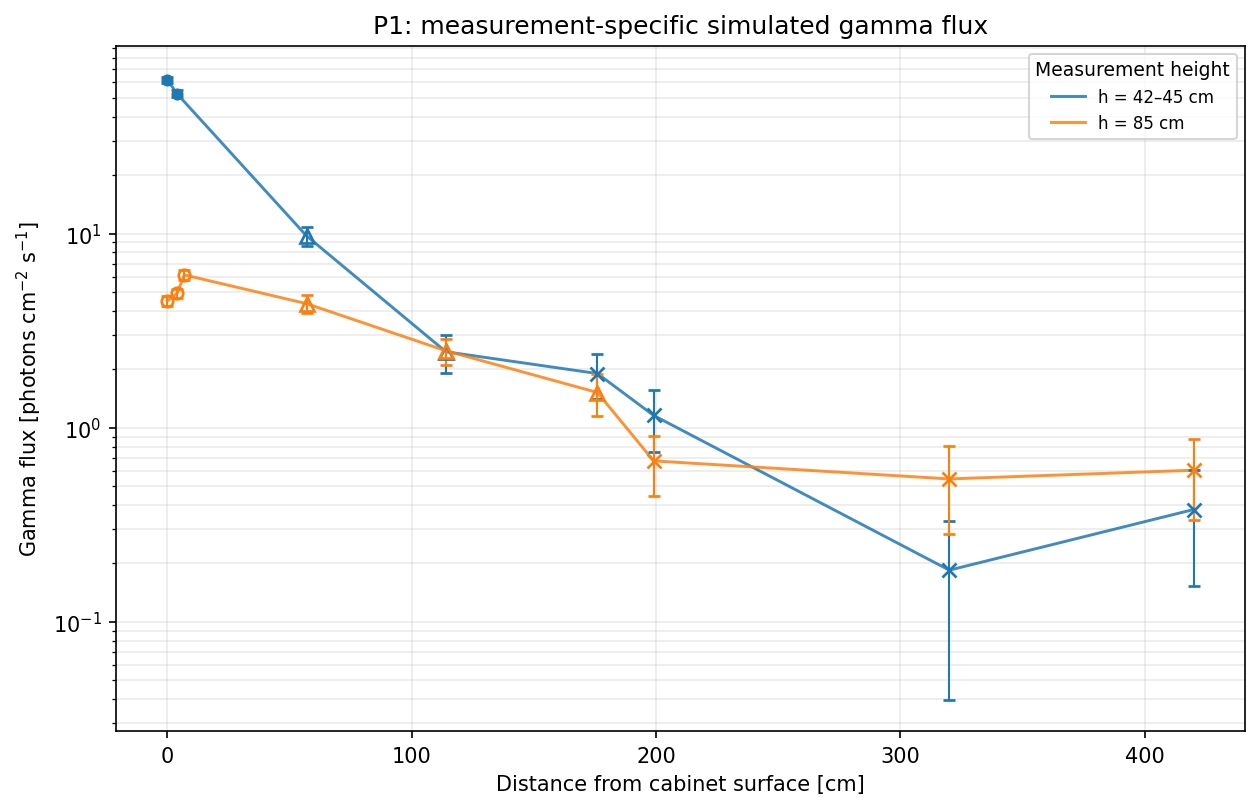

Saved figure: N2_5_simulated_gamma_outputs/figures/section_7_p1_gamma_flux_vs_distance.png


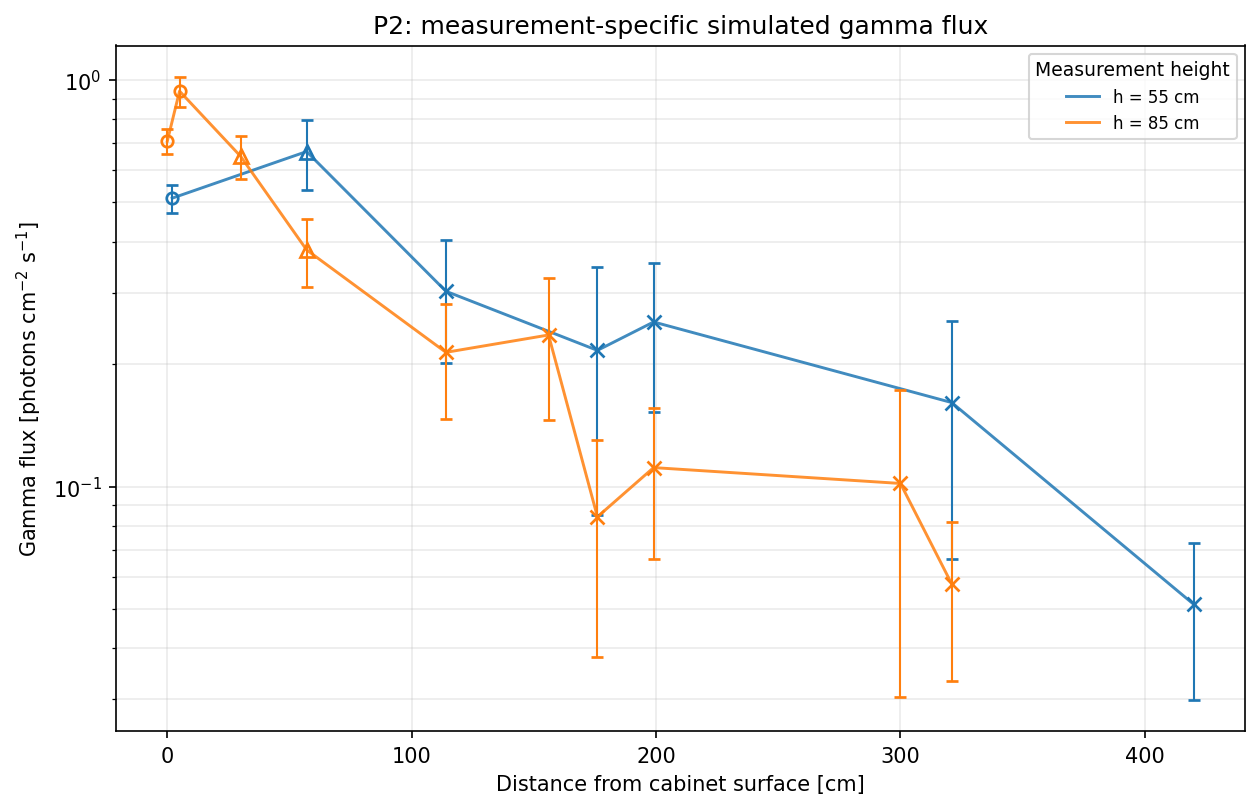

Saved figure: N2_5_simulated_gamma_outputs/figures/section_7_p2_gamma_flux_vs_distance.png


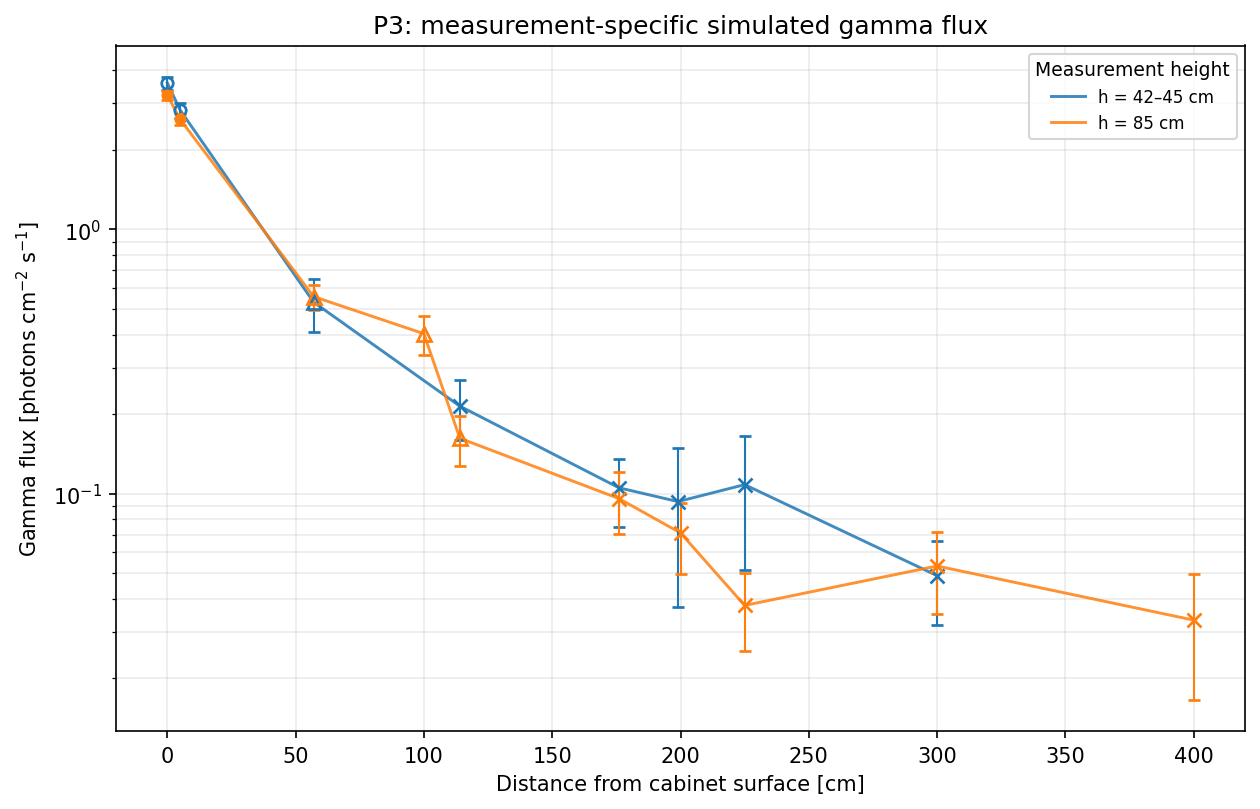

Saved figure: N2_5_simulated_gamma_outputs/figures/section_7_p3_gamma_flux_vs_distance.png


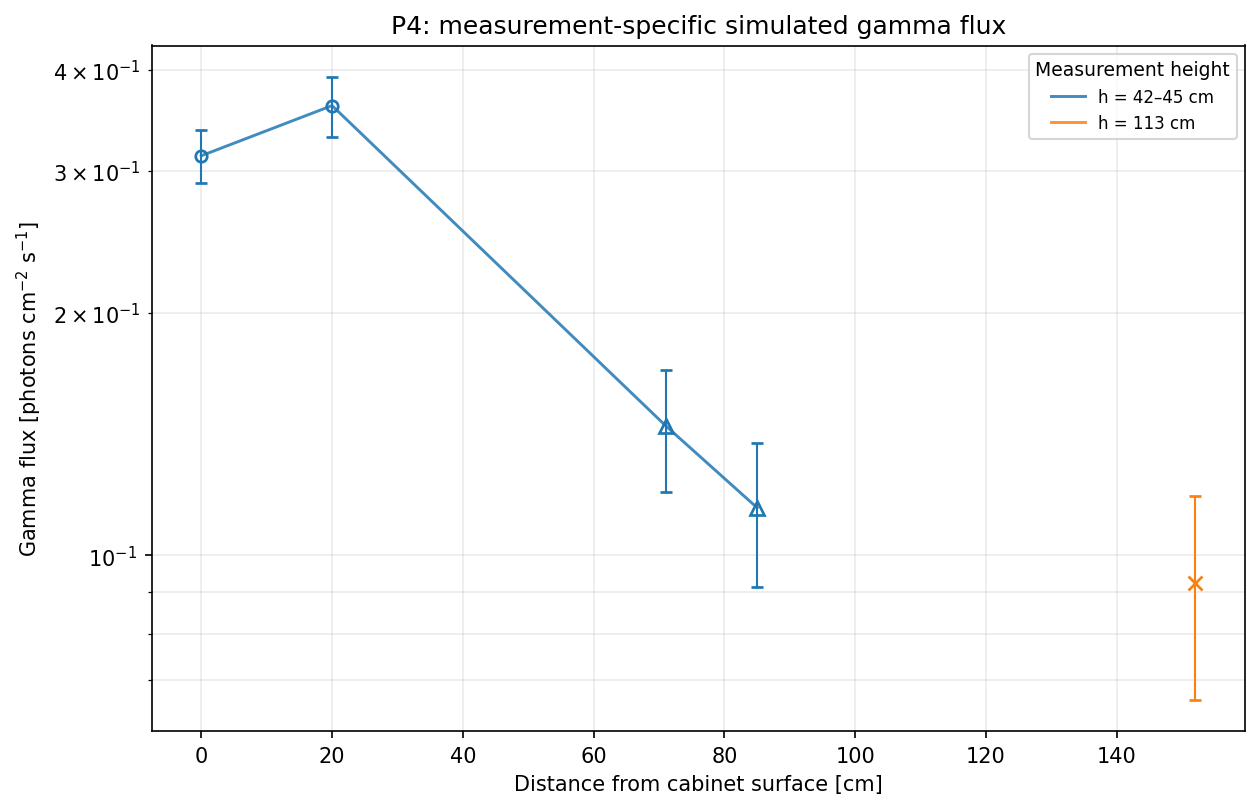

Saved figure: N2_5_simulated_gamma_outputs/figures/section_7_p4_gamma_flux_vs_distance.png


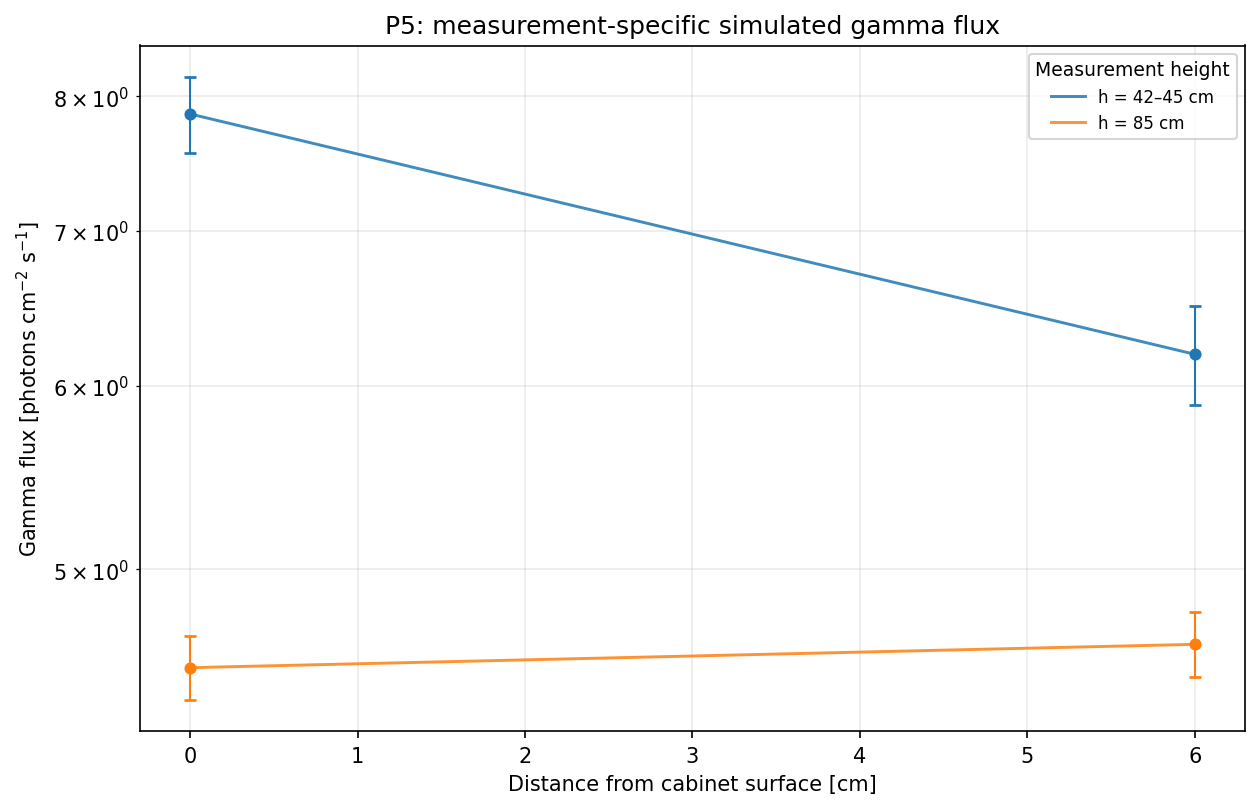

Saved figure: N2_5_simulated_gamma_outputs/figures/section_7_p5_gamma_flux_vs_distance.png


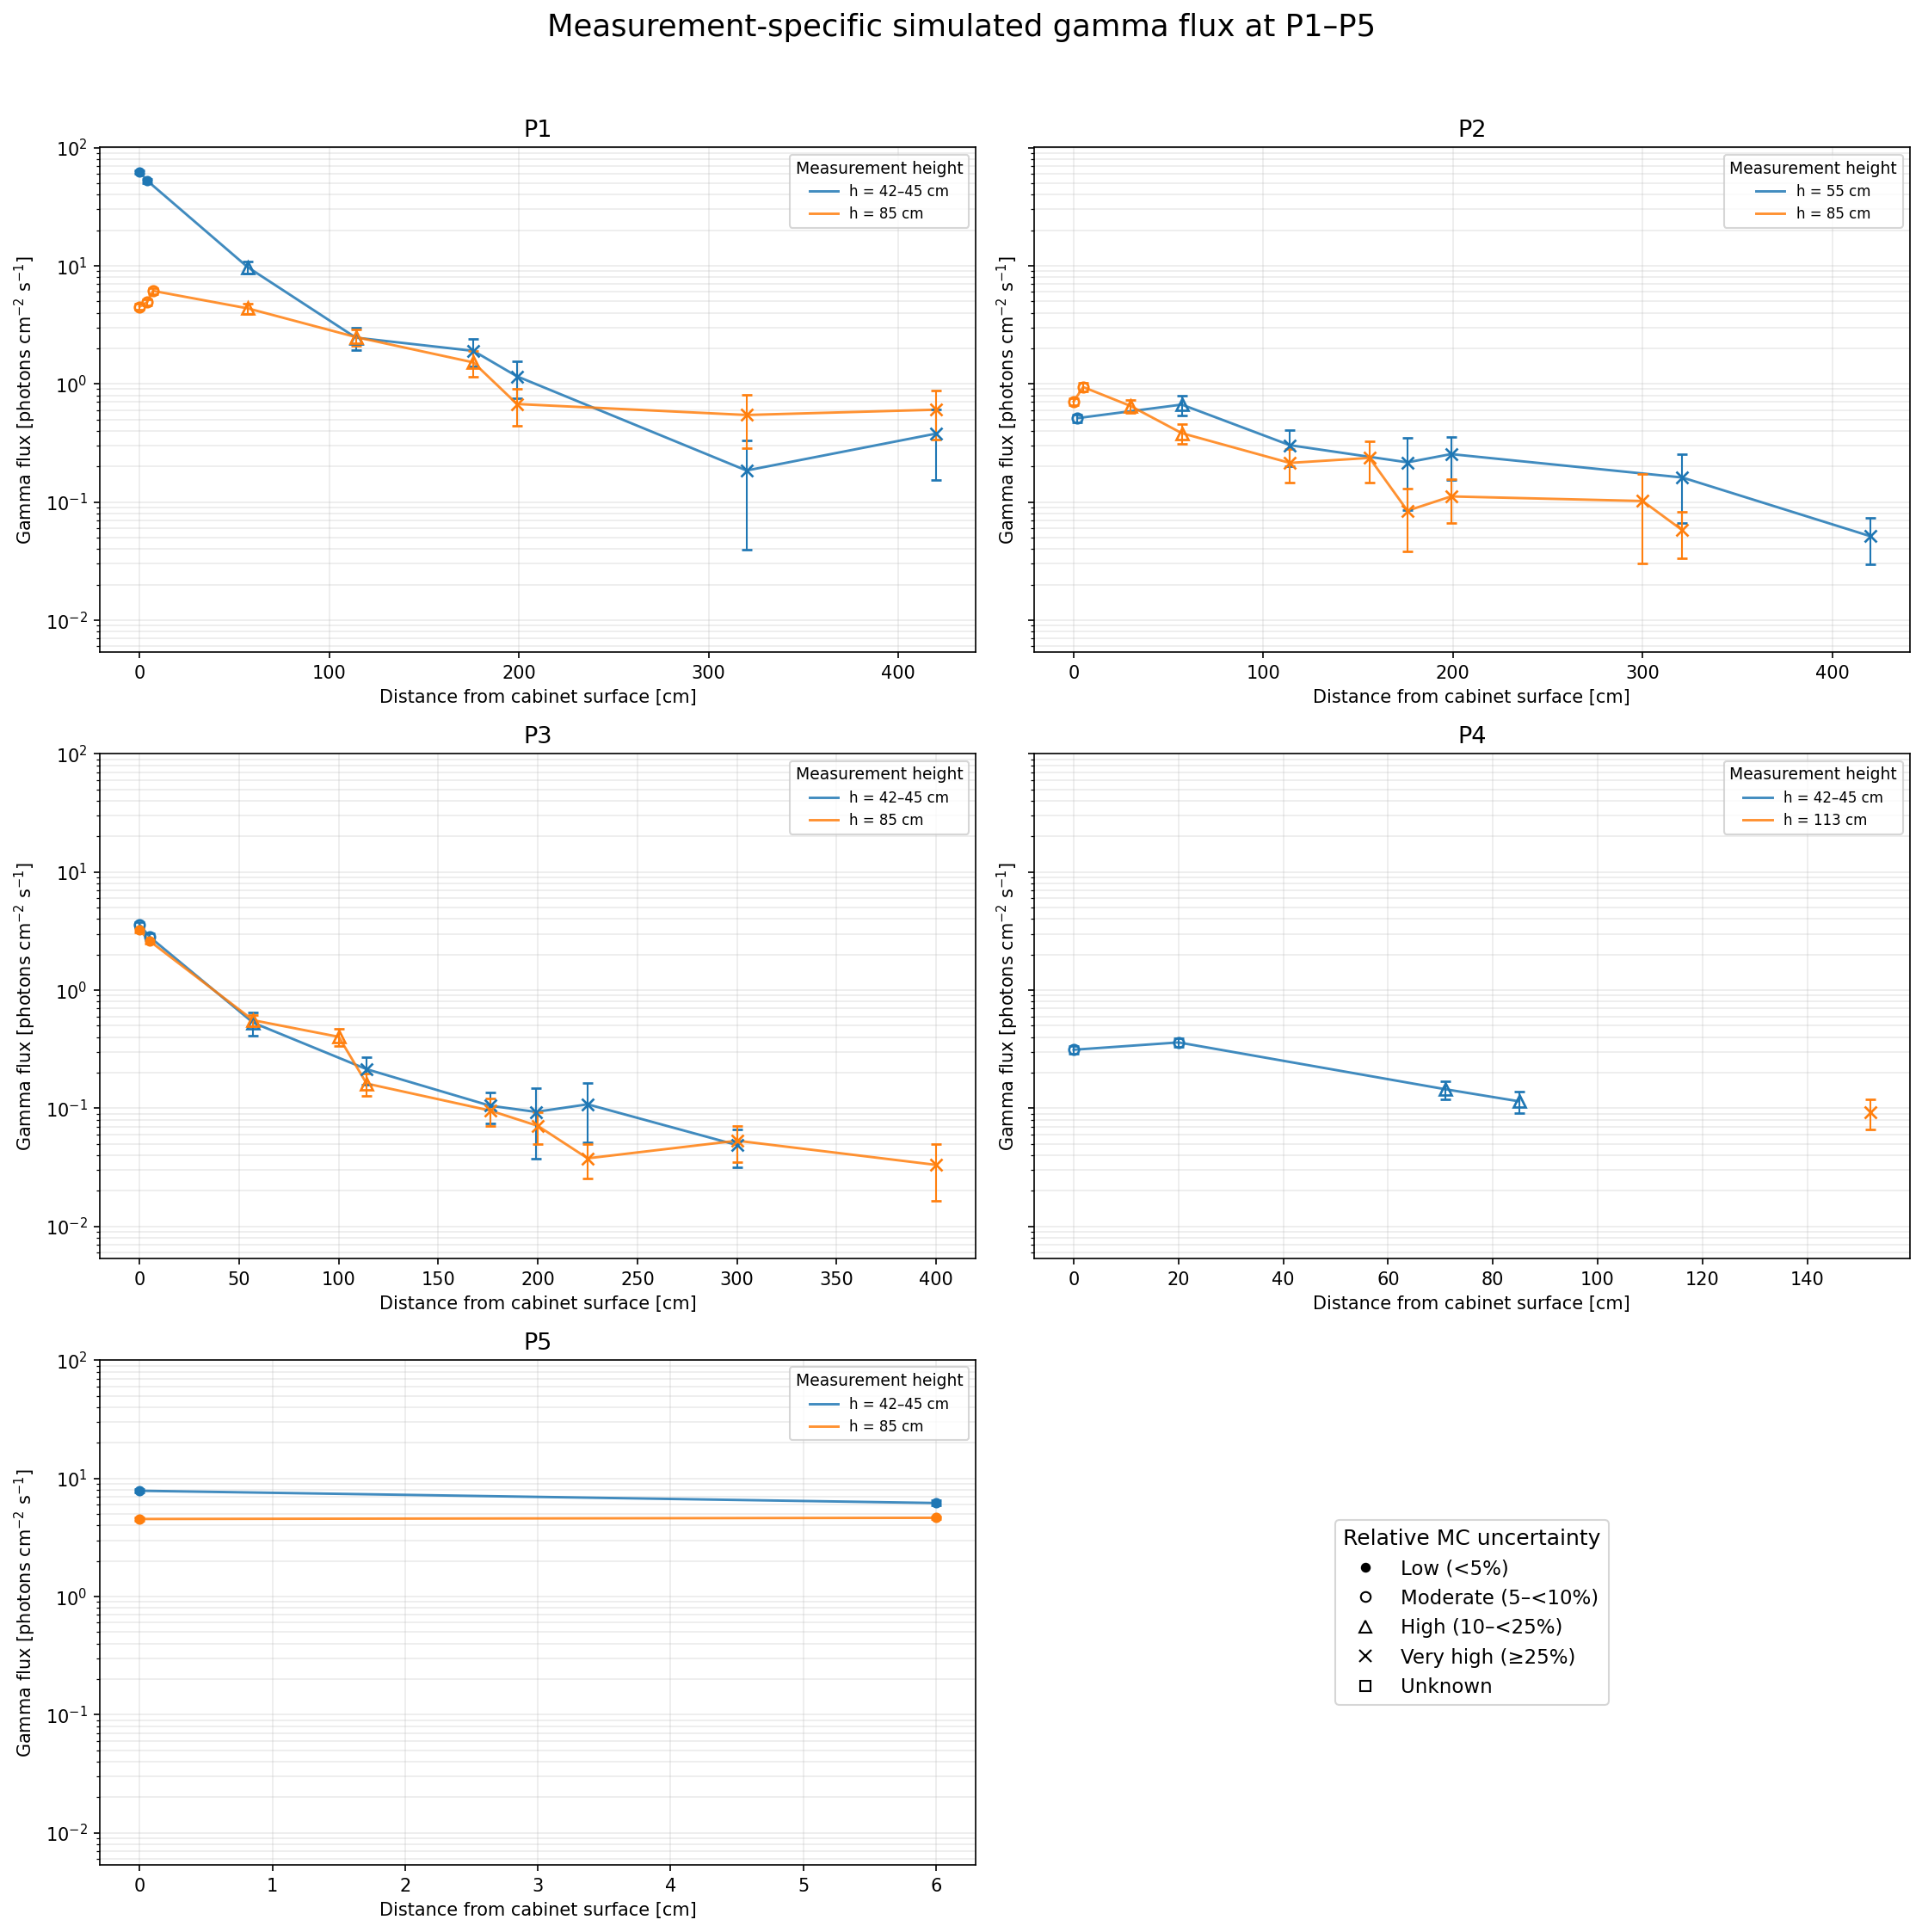

Saved combined figure: N2_5_simulated_gamma_outputs/figures/section_7_all_positions_gamma_flux_vs_distance.png


In [63]:
# ============================================================
# 7) Measurement-specific gamma flux versus distance
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Validate input from Section 6
# ------------------------------------------------------------

REQUIRED_GAMMA_SCAN_COLUMNS = {
    "position",
    "distance_cm",
    "height_cm",
    "gamma_flux_physical [photon/cm2/s]",
    "u_mc_physical [photon/cm2/s]",
    "rel_u_mc [%]",
}

missing_columns = sorted(
    REQUIRED_GAMMA_SCAN_COLUMNS
    - set(gamma_scan_summary.columns)
)

if missing_columns:
    raise KeyError(
        "gamma_scan_summary is missing the following columns: "
        + ", ".join(missing_columns)
    )


# Ensure that the figure directory exists
FIGURE_DIR = Path(FIGURE_DIR)
FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# General plot configuration
# ------------------------------------------------------------

POSITION_ORDER = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
]

MC_UNCERTAINTY_ORDER = [
    "low",
    "moderate",
    "high",
    "very high",
    "unknown",
]

# Use limits defined earlier in the notebook.
# Default values are used if they do not already exist.
MC_LOW_U_MAX_PERCENT = float(
    globals().get(
        "MC_LOW_U_MAX_PERCENT",
        5.0,
    )
)

MC_MODERATE_U_MAX_PERCENT = float(
    globals().get(
        "MC_MODERATE_U_MAX_PERCENT",
        10.0,
    )
)

MC_HIGH_U_MAX_PERCENT = float(
    globals().get(
        "MC_HIGH_U_MAX_PERCENT",
        25.0,
    )
)

# Consistent colours throughout P1–P5
LOWER_HEIGHT_COLOR = "tab:blue"
UPPER_HEIGHT_COLOR = "tab:orange"
OTHER_HEIGHT_COLOR = "tab:gray"


# ------------------------------------------------------------
# Measurement-height groups
# ------------------------------------------------------------

def height_group_key(height_cm):
    """
    Return a plotting-group identifier for one measurement height.

    Measurements at 42–45 cm are treated as one continuous
    lower-height scan. Other heights retain their exact values.
    """

    height_cm = float(height_cm)

    if 42.0 <= height_cm <= 45.0:
        return "lower_42_45"

    return f"height_{height_cm:g}"


def height_group_label(height_cm):
    """
    Return the legend label for a measurement height.
    """

    height_cm = float(height_cm)

    if 42.0 <= height_cm <= 45.0:
        return "h = 42–45 cm"

    return f"h = {height_cm:g} cm"


def height_group_color(height_cm):
    """
    Return a consistent colour for a measurement height.

    Lower measurements from 42 to 55 cm are blue.
    Upper measurements from 85 cm and above are orange.
    """

    height_cm = float(height_cm)

    if 42.0 <= height_cm <= 55.0:
        return LOWER_HEIGHT_COLOR

    if height_cm >= 85.0:
        return UPPER_HEIGHT_COLOR

    return OTHER_HEIGHT_COLOR


# ------------------------------------------------------------
# Monte Carlo uncertainty styles
# ------------------------------------------------------------

UNCERTAINTY_STYLES = {
    "low": {
        "marker": "o",
        "markerfacecolor": "color",
        "markersize": 4.5,
        "label": (
            f"Low "
            f"(<{MC_LOW_U_MAX_PERCENT:g}%)"
        ),
    },
    "moderate": {
        "marker": "o",
        "markerfacecolor": "none",
        "markersize": 5.5,
        "label": (
            f"Moderate "
            f"({MC_LOW_U_MAX_PERCENT:g}–"
            f"<{MC_MODERATE_U_MAX_PERCENT:g}%)"
        ),
    },
    "high": {
        "marker": "^",
        "markerfacecolor": "none",
        "markersize": 6.5,
        "label": (
            f"High "
            f"({MC_MODERATE_U_MAX_PERCENT:g}–"
            f"<{MC_HIGH_U_MAX_PERCENT:g}%)"
        ),
    },
    "very high": {
        "marker": "x",
        "markerfacecolor": "none",
        "markersize": 7.0,
        "label": (
            f"Very high "
            f"(≥{MC_HIGH_U_MAX_PERCENT:g}%)"
        ),
    },
    "unknown": {
        "marker": "s",
        "markerfacecolor": "none",
        "markersize": 5.5,
        "label": "Unknown",
    },
}


def uncertainty_masks(relative_uncertainty):
    """
    Return Boolean masks for the MC uncertainty classes.
    """

    relative_uncertainty = np.asarray(
        relative_uncertainty,
        dtype=float,
    )

    finite = np.isfinite(
        relative_uncertainty
    )

    return {
        "low": (
            finite
            & (
                relative_uncertainty
                < MC_LOW_U_MAX_PERCENT
            )
        ),
        "moderate": (
            finite
            & (
                relative_uncertainty
                >= MC_LOW_U_MAX_PERCENT
            )
            & (
                relative_uncertainty
                < MC_MODERATE_U_MAX_PERCENT
            )
        ),
        "high": (
            finite
            & (
                relative_uncertainty
                >= MC_MODERATE_U_MAX_PERCENT
            )
            & (
                relative_uncertainty
                < MC_HIGH_U_MAX_PERCENT
            )
        ),
        "very high": (
            finite
            & (
                relative_uncertainty
                >= MC_HIGH_U_MAX_PERCENT
            )
        ),
        "unknown": ~finite,
    }


def add_uncertainty_errorbars(
    ax,
    x,
    y,
    yerr,
    relative_uncertainty,
    color,
):
    """
    Add error bars and markers based on the relative
    Monte Carlo uncertainty.
    """

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    yerr = np.asarray(
        yerr,
        dtype=float,
    )

    relative_uncertainty = np.asarray(
        relative_uncertainty,
        dtype=float,
    )

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(yerr)
        & (y > 0.0)
        & (yerr >= 0.0)
    )

    class_masks = uncertainty_masks(
        relative_uncertainty
    )

    for class_name in MC_UNCERTAINTY_ORDER:
        mask = (
            valid
            & class_masks[class_name]
        )

        if not np.any(mask):
            continue

        style = UNCERTAINTY_STYLES[
            class_name
        ]

        markerfacecolor = style[
            "markerfacecolor"
        ]

        if markerfacecolor == "color":
            markerfacecolor = color

        ax.errorbar(
            x[mask],
            y[mask],
            yerr=yerr[mask],
            fmt=style["marker"],
            linestyle="none",
            color=color,
            ecolor=color,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markersize=style["markersize"],
            markeredgewidth=1.3,
            capsize=3,
            elinewidth=1.0,
            zorder=3,
            label="_nolegend_",
        )


def make_uncertainty_legend_handles():
    """
    Create handles for the shared MC uncertainty legend.
    """

    handles = []

    for class_name in MC_UNCERTAINTY_ORDER:
        style = UNCERTAINTY_STYLES[
            class_name
        ]

        markerfacecolor = (
            "black"
            if style["markerfacecolor"] == "color"
            else "none"
        )

        handles.append(
            Line2D(
                [0],
                [0],
                marker=style["marker"],
                linestyle="none",
                color="black",
                markerfacecolor=markerfacecolor,
                markeredgecolor="black",
                markersize=style["markersize"],
                label=style["label"],
            )
        )

    return handles


# ------------------------------------------------------------
# Draw one P1–P5 scan direction
# ------------------------------------------------------------

def draw_gamma_scan_direction(
    ax,
    dataframe,
    position,
    combined_figure=False,
):
    """
    Draw gamma flux versus distance for one position.

    Measurements at 42 and 45 cm are combined into the
    same 42–45 cm plotting group. All connecting curves
    are fully solid.
    """

    subset = dataframe.loc[
        dataframe["position"] == position
    ].copy()

    if subset.empty:
        ax.set_visible(False)

        print(
            f"No gamma data found for {position}."
        )

        return False

    # Assign each measurement to a plotting group.
    subset["_height_group"] = subset[
        "height_cm"
    ].apply(height_group_key)

    # Sort groups according to their lowest physical height.
    group_order = (
        subset.groupby("_height_group")[
            "height_cm"
        ]
        .min()
        .sort_values()
        .index
        .tolist()
    )

    for group_key in group_order:
        height_data = subset.loc[
            subset["_height_group"] == group_key
        ].copy()

        # The representative height determines colour and label.
        representative_height = float(
            height_data["height_cm"].min()
        )

        color = height_group_color(
            representative_height
        )

        label = height_group_label(
            representative_height
        )

        # Combine the 42 cm and 45 cm measurements into
        # one distance-ordered curve.
        height_data = height_data.sort_values(
            "distance_cm"
        )

        x = height_data[
            "distance_cm"
        ].to_numpy(dtype=float)

        y = height_data[
            "gamma_flux_physical [photon/cm2/s]"
        ].to_numpy(dtype=float)

        yerr = height_data[
            "u_mc_physical [photon/cm2/s]"
        ].to_numpy(dtype=float)

        relative_uncertainty = height_data[
            "rel_u_mc [%]"
        ].to_numpy(dtype=float)

        # Avoid plotting invalid or non-positive values
        # on the logarithmic y-axis.
        line_y = np.where(
            np.isfinite(y) & (y > 0.0),
            y,
            np.nan,
        )

        # All connecting curves are fully solid.
        ax.plot(
            x,
            line_y,
            color=color,
            linestyle="-",
            linewidth=1.4,
            alpha=0.85,
            label=label,
            zorder=2,
        )

        add_uncertainty_errorbars(
            ax=ax,
            x=x,
            y=y,
            yerr=yerr,
            relative_uncertainty=(
                relative_uncertainty
            ),
            color=color,
        )

    ax.set_yscale("log")

    ax.set_xlabel(
        "Distance from cabinet surface [cm]"
    )

    ax.set_ylabel(
        r"Gamma flux "
        r"[photons cm$^{-2}$ s$^{-1}$]"
    )

    if combined_figure:
        ax.set_title(
            position,
            fontsize=13,
            fontweight="normal",
        )
    else:
        ax.set_title(
            f"{position}: measurement-specific "
            "simulated gamma flux",
            fontweight="normal",
        )

    ax.grid(
        True,
        which="both",
        alpha=0.25,
    )

    # Each plot only contains its measurement-height legend.
    ax.legend(
        title="Measurement height",
        loc="upper right",
        fontsize=8,
        title_fontsize=9,
    )

    return True


# ------------------------------------------------------------
# Individual P1–P5 figures
# ------------------------------------------------------------

def plot_gamma_scan_direction(
    dataframe,
    position,
):
    """
    Plot and save one position without the shared
    MC uncertainty legend.
    """

    fig, ax = plt.subplots(
        figsize=(8.5, 5.5),
        dpi=150,
    )

    data_found = draw_gamma_scan_direction(
        ax=ax,
        dataframe=dataframe,
        position=position,
        combined_figure=False,
    )

    if not data_found:
        plt.close(fig)
        return

    fig.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            f"section_7_{position.lower()}"
            "_gamma_flux_vs_distance.png"
        )
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        f"Saved figure: {figure_path}"
    )


# ------------------------------------------------------------
# Combined P1–P5 figure
# ------------------------------------------------------------

def plot_all_gamma_scan_directions(
    dataframe,
):
    """
    Combine P1–P5 in a 3×2 figure.

    The sixth panel contains the shared Monte Carlo
    uncertainty legend.
    """

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(15, 15),
        dpi=150,
        sharey=True,
    )

    axes = axes.ravel()

    for ax, position in zip(
        axes[:5],
        POSITION_ORDER,
    ):
        draw_gamma_scan_direction(
            ax=ax,
            dataframe=dataframe,
            position=position,
            combined_figure=True,
        )

    # Use the empty sixth panel for the shared legend.
    legend_ax = axes[5]
    legend_ax.axis("off")

    legend_ax.legend(
        handles=(
            make_uncertainty_legend_handles()
        ),
        title="Relative MC uncertainty",
        loc="center",
        fontsize=11,
        title_fontsize=12,
        frameon=True,
    )

    fig.suptitle(
        "Measurement-specific simulated "
        "gamma flux at P1–P5",
        fontsize=17,
        fontweight="normal",
        y=0.995,
    )

    fig.tight_layout(
        rect=[0.0, 0.0, 1.0, 0.975]
    )

    figure_path = (
        FIGURE_DIR
        / (
            "section_7_all_positions"
            "_gamma_flux_vs_distance.png"
        )
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        f"Saved combined figure: "
        f"{figure_path}"
    )


# ------------------------------------------------------------
# Generate and save all Section 7 figures
# ------------------------------------------------------------

for scan_position in POSITION_ORDER:
    plot_gamma_scan_direction(
        gamma_scan_summary,
        scan_position,
    )

plot_all_gamma_scan_directions(
    gamma_scan_summary
)

# 7.1) Direction comparison by height group

The lower group contains measurements from 42–55 cm, while the upper group
contains measurements at 85 cm and above. Curves are grouped by both
direction and exact height. This avoids drawing a single connecting line
through points measured at different heights within the same broad group.

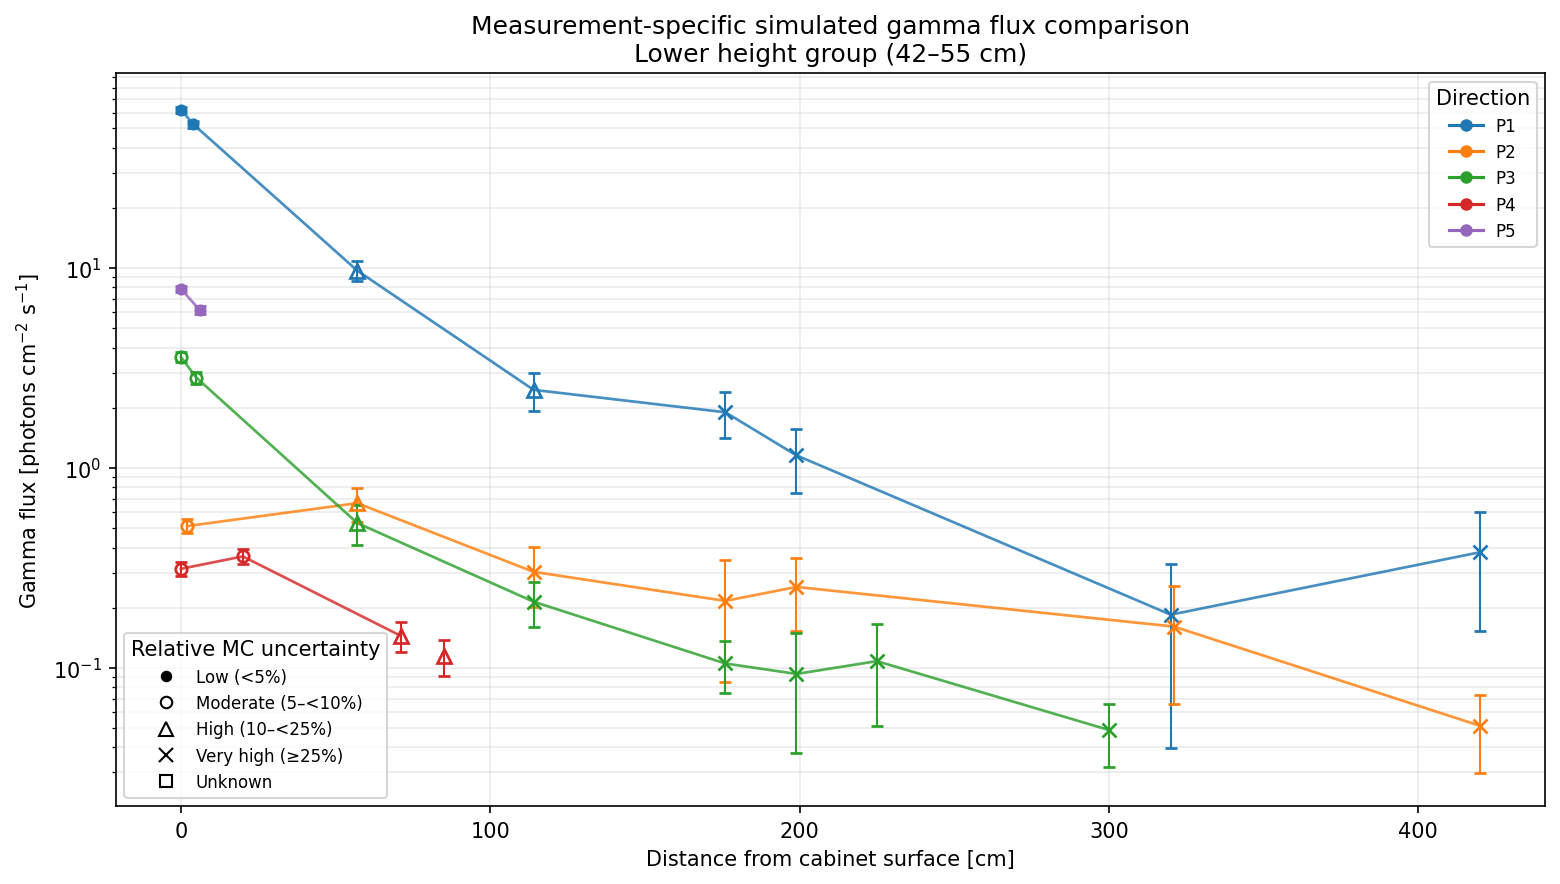

Saved figure: N2_5_simulated_gamma_outputs/figures/section_7_1_lower_height_42_55_cm_gamma_comparison.png


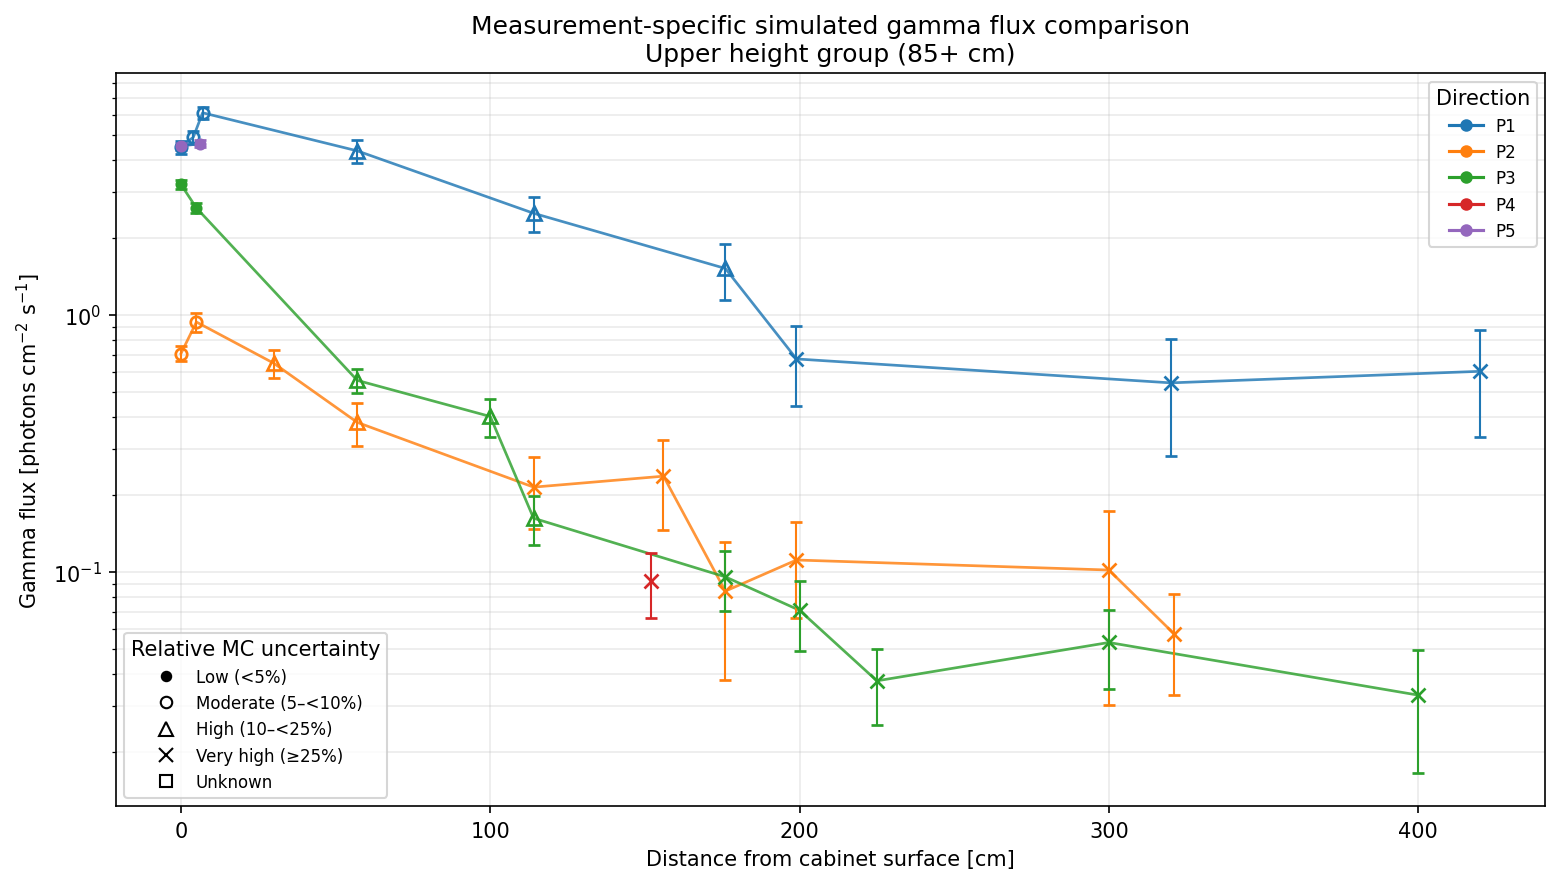

Saved figure: N2_5_simulated_gamma_outputs/figures/section_7_1_upper_height_85_plus_cm_gamma_comparison.png

Height-group summary:


,height_group,position,number_of_points
0,Lower height group (42–55 cm),P1,8
1,Lower height group (42–55 cm),P2,7
2,Lower height group (42–55 cm),P3,8
3,Lower height group (42–55 cm),P4,4
4,Lower height group (42–55 cm),P5,2
5,Upper height group (85+ cm),P1,9
6,Upper height group (85+ cm),P2,10
7,Upper height group (85+ cm),P3,10
8,Upper height group (85+ cm),P4,1
9,Upper height group (85+ cm),P5,2


In [64]:
def assign_height_group(height_cm):
    if 42.0 <= height_cm <= 55.0:
        return "Lower height group (42–55 cm)"
    if height_cm >= 85.0:
        return "Upper height group (85+ cm)"
    return "Other heights"


gamma_scan_summary_grouped = gamma_scan_summary.copy()
gamma_scan_summary_grouped["height_group"] = (
    gamma_scan_summary_grouped["height_cm"]
    .apply(assign_height_group)
)

position_order = ["P1", "P2", "P3", "P4", "P5"]
position_colors = {
    position: plt.get_cmap("tab10")(index)
    for index, position in enumerate(position_order)
}


def plot_gamma_height_group_comparison(
    dataframe,
    height_group,
    filename_tag,
):
    """Plot and save all directions for one height group."""

    subset = dataframe[
        dataframe["height_group"] == height_group
    ].copy()

    if subset.empty:
        print(f"No gamma data found for {height_group}.")
        return

    fig, ax = plt.subplots(figsize=(10.5, 6.0), dpi=150)

    for (position, height_cm), curve_data in subset.groupby(
        ["position", "height_cm"],
        sort=True,
    ):
        curve_data = curve_data.sort_values("distance_cm")

        x = curve_data["distance_cm"].to_numpy()
        y = curve_data[
            "gamma_flux_physical [photon/cm2/s]"
        ].to_numpy()
        yerr = curve_data[
            "u_mc_physical [photon/cm2/s]"
        ].to_numpy()
        relative_uncertainty = curve_data[
            "rel_u_mc [%]"
        ].to_numpy()

        color = position_colors[position]

        ax.plot(
            x,
            y,
            color=color,
            linewidth=1.3,
            alpha=0.82,
            label=f"{position}, h = {height_cm:g} cm",
        )

        add_uncertainty_errorbars(
            ax=ax,
            x=x,
            y=y,
            yerr=yerr,
            relative_uncertainty=relative_uncertainty,
            color=color,
        )

    ax.set_yscale("log")
    ax.set_xlabel("Distance from cabinet surface [cm]")
    ax.set_ylabel(r"Gamma flux [photons cm$^{-2}$ s$^{-1}$]")
    ax.set_title(
        "Measurement-specific simulated gamma flux comparison\n"
        f"{height_group}"
    )
    ax.grid(True, which="both", alpha=0.25)

    # Separate legend showing the P1–P5 directions
    
    available_positions = [position for position in position_order if position in subset["position"].unique()]

    direction_handles = [
    Line2D(
        [0],
        [0],
        color=position_colors[position],
        linewidth=1.5,
        marker="o",
        markerfacecolor=position_colors[position],
        markeredgecolor=position_colors[position],
        markersize=5,
        label=position,)
    for position in available_positions]

    direction_legend = ax.legend(
    handles=direction_handles,
    title="Direction",
    loc="upper right",
    fontsize=8,)

    ax.add_artist(direction_legend)

    # Separate legend for the uncertainty classes
    ax.legend(
    handles=make_uncertainty_legend_handles(),
    title="Relative MC uncertainty",
    loc="lower left",
    fontsize=8,)

    fig.tight_layout()

    figure_path = (
        FIGURE_DIR
        / f"section_7_1_{filename_tag}_gamma_comparison.png"
    )
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved figure: {figure_path}")


height_group_plots = [
    (
        "Lower height group (42–55 cm)",
        "lower_height_42_55_cm",
    ),
    (
        "Upper height group (85+ cm)",
        "upper_height_85_plus_cm",
    ),
]

for height_group, filename_tag in height_group_plots:
    plot_gamma_height_group_comparison(
        gamma_scan_summary_grouped,
        height_group,
        filename_tag,
    )


print()
print("Height-group summary:")
display(
    gamma_scan_summary_grouped
    .groupby(["height_group", "position"])
    .size()
    .rename("number_of_points")
    .reset_index()
)

# 8) Monte Carlo uncertainty check

The quality flag assesses only the OpenMC batch-statistical standard
uncertainty. It is not a total simulation-uncertainty classification.

Points with $u_{\mathrm{rel,MC}}\geq25\%$ are retained for completeness,
but they should be interpreted qualitatively and should not support strong
quantitative conclusions.

,position,mc_uncertainty_class,count
0,P1,low,2
1,P1,moderate,3
2,P1,high,5
3,P1,very high,7
4,P2,moderate,3
5,P2,high,3
6,P2,very high,11
7,P3,low,2
8,P3,moderate,2
9,P3,high,4



Number of points with relative Monte Carlo uncertainty >= 25%: 29


,position,point_name,distance_cm,height_cm,gamma_flux_physical [photon/cm2/s],u_mc_physical [photon/cm2/s],rel_u_mc [%],mc_uncertainty_class
0,P1,P1_x176_h42,176.0,42.0,1.900014,0.494173,26.008911,very high
1,P1,P1_x199_h42,199.0,42.0,1.156677,0.407852,35.260685,very high
2,P1,P1_x320_h42,320.0,42.0,0.184597,0.144965,78.530725,very high
3,P1,P1_x420_h42,420.0,42.0,0.378990,0.225959,59.621350,very high
4,P1,P1_x199_h85,199.0,85.0,0.674699,0.230569,34.173658,very high
5,P1,P1_x320_h85,320.0,85.0,0.544575,0.261596,48.036642,very high
6,P1,P1_x420_h85,420.0,85.0,0.603920,0.268745,44.500059,very high
7,P2,P2_x114_h55,114.0,55.0,0.302379,0.100825,33.344061,very high
8,P2,P2_x176_h55,176.0,55.0,0.216336,0.131321,60.702328,very high
9,P2,P2_x199_h55,199.0,55.0,0.254111,0.101123,39.795071,very high


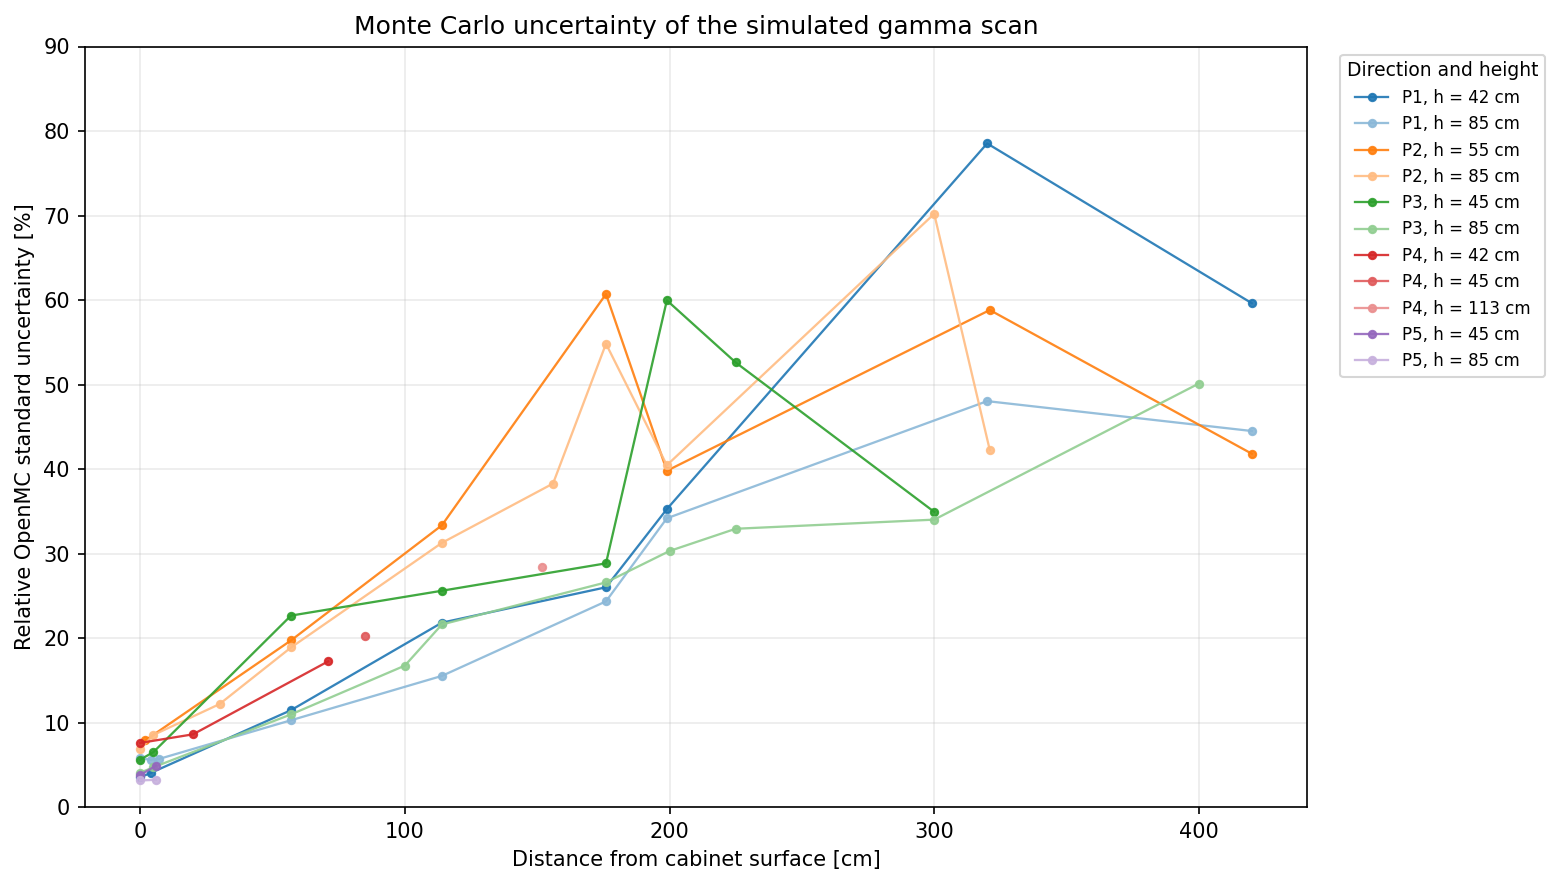

Saved figure: N2_5_simulated_gamma_outputs/figures/section_8_gamma_relative_mc_uncertainty.png


In [65]:
from matplotlib.colors import to_rgb


uncertainty_class_counts = (
    gamma_scan_summary
    .groupby(
        ["position", "mc_uncertainty_class"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

display(uncertainty_class_counts)


very_high_uncertainty_points = (
    gamma_scan_summary.loc[
        gamma_scan_summary["mc_uncertainty_class"] == "very high",
        [
            "position",
            "point_name",
            "distance_cm",
            "height_cm",
            "gamma_flux_physical [photon/cm2/s]",
            "u_mc_physical [photon/cm2/s]",
            "rel_u_mc [%]",
            "mc_uncertainty_class",
        ],
    ]
    .sort_values(
        [
            "position",
            "height_cm",
            "distance_cm",
        ]
    )
    .reset_index(drop=True)
)

print()
print(
    "Number of points with relative Monte Carlo uncertainty "
    f">= 25%: {len(very_high_uncertainty_points)}"
)

if not very_high_uncertainty_points.empty:
    display(very_high_uncertainty_points)


# ------------------------------------------------------------
# Relative Monte Carlo uncertainty versus distance
# ------------------------------------------------------------

def lighten_color(color, amount):
    """
    Blend a colour with white.

    Parameters
    ----------
    color : matplotlib-compatible colour
        Base colour assigned to the position.
    amount : float
        Fraction of white mixed into the base colour.
        A value of 0 returns the original colour, while
        larger values produce lighter shades.
    """

    base_rgb = np.asarray(
        to_rgb(color),
        dtype=float,
    )

    white_rgb = np.ones(3)

    return tuple(
        (1.0 - amount) * base_rgb
        + amount * white_rgb
    )


# Create one shade for each position-height combination.
# The lowest height uses the darkest shade, while increasing
# heights use progressively lighter shades of the same colour.

position_height_colors = {}

for position, position_data in gamma_scan_summary.groupby(
    "position",
    sort=True,
):
    available_heights = np.sort(
        position_data[
            "height_cm"
        ].dropna().unique()
    )

    number_of_heights = len(
        available_heights
    )

    if number_of_heights == 1:
        lightening_amounts = np.array([0.0])

    else:
        lightening_amounts = np.linspace(
            0.0,
            0.48,
            number_of_heights,
        )

    for height_cm, lightening_amount in zip(
        available_heights,
        lightening_amounts,
    ):
        position_height_colors[
            (position, height_cm)
        ] = lighten_color(
            position_colors[position],
            lightening_amount,
        )


fig, ax = plt.subplots(
    figsize=(10.5, 6.0),
    dpi=150,
)


for (
    position,
    height_cm,
), curve_data in gamma_scan_summary.groupby(
    [
        "position",
        "height_cm",
    ],
    sort=True,
):
    curve_data = curve_data.sort_values(
        "distance_cm"
    )

    x = curve_data[
        "distance_cm"
    ].to_numpy(dtype=float)

    y = curve_data[
        "rel_u_mc [%]"
    ].to_numpy(dtype=float)

    valid_points = (
        np.isfinite(x)
        & np.isfinite(y)
        & (y >= 0.0)
    )

    if not np.any(valid_points):
        continue

    curve_color = position_height_colors[
        (position, height_cm)
    ]

    ax.plot(
        x[valid_points],
        y[valid_points],
        marker="o",
        markersize=3.5,
        linewidth=1.1,
        alpha=0.90,
        color=curve_color,
        label=(
            f"{position}, "
            f"h = {height_cm:g} cm"
        ),
    )


# ------------------------------------------------------------
# Linear y-axis
# ------------------------------------------------------------

finite_uncertainties = gamma_scan_summary.loc[
    np.isfinite(
        gamma_scan_summary[
            "rel_u_mc [%]"
        ]
    )
    & (
        gamma_scan_summary[
            "rel_u_mc [%]"
        ]
        >= 0.0
    ),
    "rel_u_mc [%]",
]

if not finite_uncertainties.empty:
    maximum_uncertainty = (
        finite_uncertainties.max()
    )

    # Add approximately 10% space above the largest value
    # and round the upper limit to the next multiple of 5%.
    upper_y_limit = max(
        10.0,
        5.0
        * np.ceil(
            1.10
            * maximum_uncertainty
            / 5.0
        ),
    )

    ax.set_ylim(
        0.0,
        upper_y_limit,
    )


# ------------------------------------------------------------
# Figure formatting
# ------------------------------------------------------------

ax.set_xlabel(
    "Distance from cabinet surface [cm]"
)

ax.set_ylabel(
    "Relative OpenMC standard uncertainty [%]"
)

ax.set_title(
    "Monte Carlo uncertainty of the simulated gamma scan",
    fontweight="normal",
)

ax.grid(
    True,
    which="major",
    alpha=0.25,
)

ax.legend(
    title="Direction and height",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=8,
    title_fontsize=9,
    frameon=True,
)

fig.tight_layout()


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

uncertainty_figure_path = (
    FIGURE_DIR
    / "section_8_gamma_relative_mc_uncertainty.png"
)

fig.savefig(
    uncertainty_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Saved figure: {uncertainty_figure_path}"
)

# 9) Save final gamma-simulation outputs

The final detector-specific flux table is saved both in the notebook folder
for compatibility with later notebooks and in the organized Notebook 2.5
output folder. The uncertainty summaries, metadata and every generated figure
are saved with descriptive filenames.

The metadata records the LND 712 effective diameter, effective length, active
volume, distance-reference convention, orientation assumption and the primary
manufacturer sources. The exported column `mc_uncertainty_class` uses the 5%,
10% and 25% limits defined in Section 6. Values of 25% or more are classified
as `very high`.

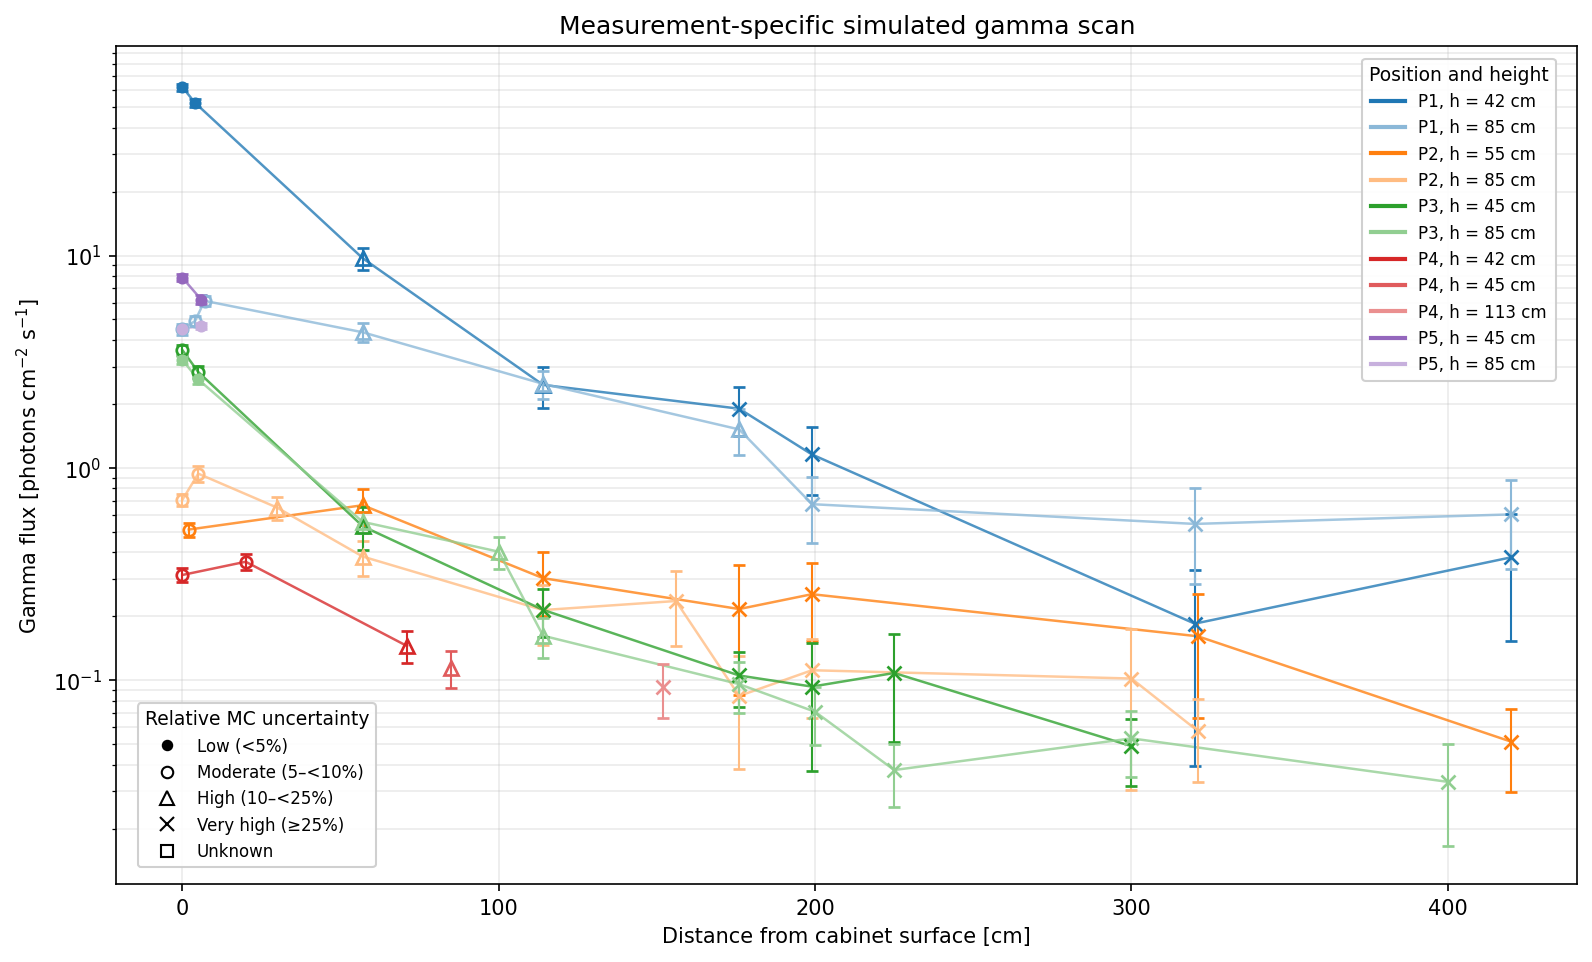

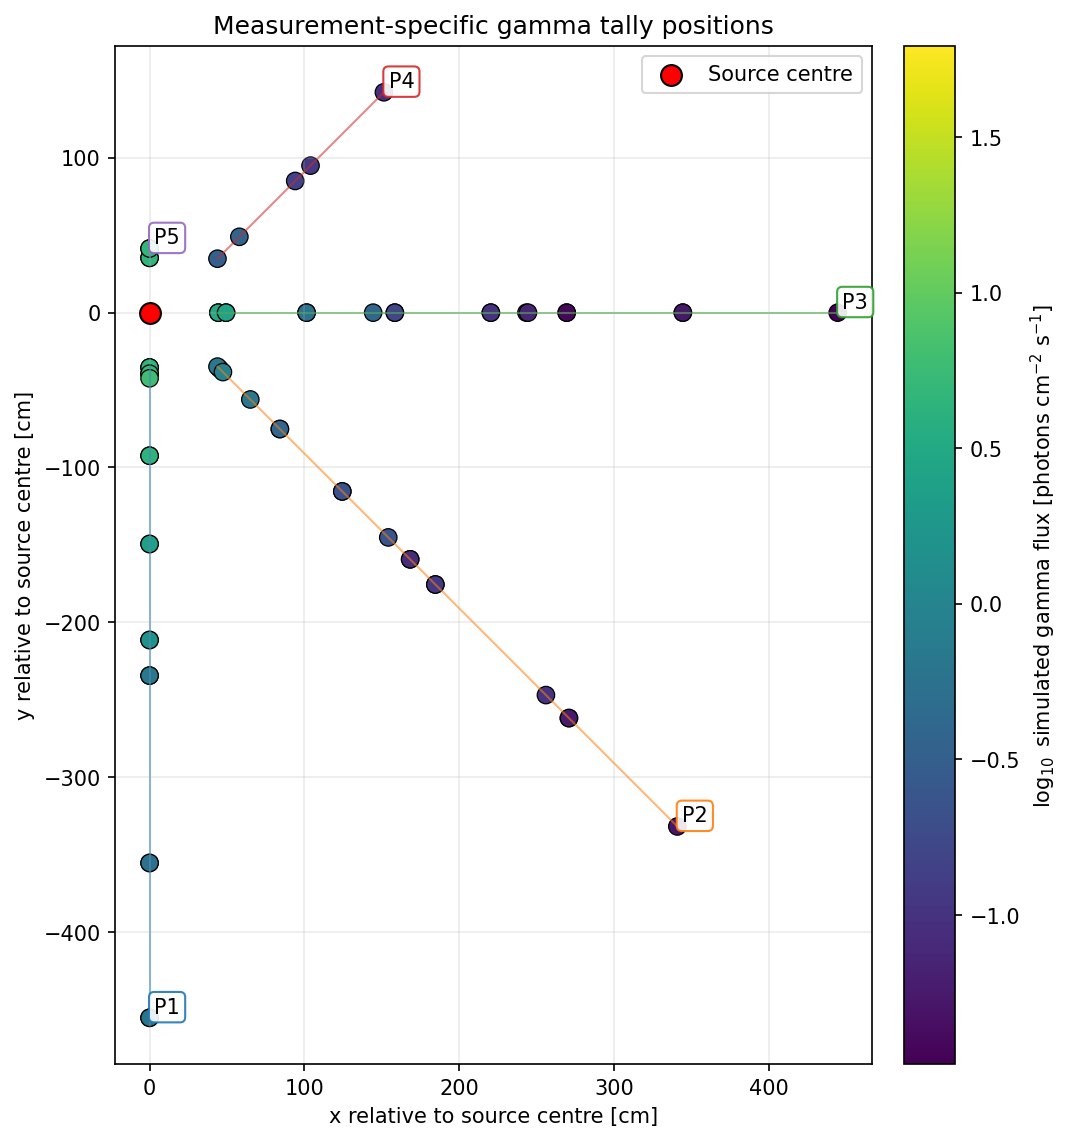

Saved final gamma scan outputs:
  Main table:       measurement_specific_gamma_scan_summary_final.csv
  Organized table:  N2_5_simulated_gamma_outputs/tables/measurement_specific_gamma_scan_summary_final.csv
  Metadata:         N2_5_simulated_gamma_outputs/metadata/measurement_specific_gamma_scan_metadata.csv
  Overview figure:  N2_5_simulated_gamma_outputs/figures/measurement_specific_gamma_flux_vs_distance.png
  Spatial map:      N2_5_simulated_gamma_outputs/figures/measurement_specific_gamma_scan_xy_map.png

Total number of saved figures: 12
  N2_5_simulated_gamma_outputs/figures/measurement_specific_gamma_flux_vs_distance.png
  N2_5_simulated_gamma_outputs/figures/measurement_specific_gamma_scan_xy_map.png
  N2_5_simulated_gamma_outputs/figures/section_2_ambe_gamma_emission_lines.png
  N2_5_simulated_gamma_outputs/figures/section_7_1_lower_height_42_55_cm_gamma_comparison.png
  N2_5_simulated_gamma_outputs/figures/section_7_1_upper_height_85_plus_cm_gamma_comparison.png
  N2_5_simu

In [66]:
# ============================================================
# Save final gamma-scan results, figures, and metadata
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Save final data tables
# ------------------------------------------------------------

gamma_scan_summary_final = gamma_scan_summary.copy()

main_gamma_output_csv = Path(
    "measurement_specific_gamma_scan_summary_final.csv"
)

organized_gamma_output_csv = (
    TABLE_DIR
    / "measurement_specific_gamma_scan_summary_final.csv"
)

uncertainty_counts_csv = (
    TABLE_DIR
    / "gamma_mc_uncertainty_class_counts.csv"
)

very_high_uncertainty_csv = (
    TABLE_DIR
    / "gamma_very_high_mc_uncertainty_points.csv"
)

gamma_scan_summary_final.to_csv(
    main_gamma_output_csv,
    index=False,
)

gamma_scan_summary_final.to_csv(
    organized_gamma_output_csv,
    index=False,
)

uncertainty_class_counts.to_csv(
    uncertainty_counts_csv,
    index=False,
)

very_high_uncertainty_points.to_csv(
    very_high_uncertainty_csv,
    index=False,
)


# ------------------------------------------------------------
# Determine the positions present in the final dataset
# ------------------------------------------------------------

preferred_position_order = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
]

available_positions = set(
    gamma_scan_summary_final[
        "position"
    ].dropna()
)

position_order = [
    position
    for position in preferred_position_order
    if position in available_positions
]

# Include any unexpected positions after P1–P5.
position_order.extend(
    sorted(
        available_positions
        - set(position_order)
    )
)

missing_position_colors = [
    position
    for position in position_order
    if position not in position_colors
]

if missing_position_colors:
    raise KeyError(
        "No colour has been defined in position_colors for: "
        + ", ".join(missing_position_colors)
    )


# ------------------------------------------------------------
# Create height-dependent shades of each position colour
# ------------------------------------------------------------

def lighten_color(color, amount):
    """
    Blend a Matplotlib colour with white.

    Parameters
    ----------
    color : Matplotlib-compatible colour
        The base colour assigned to the position.

    amount : float
        Fraction of white mixed into the base colour.
        A value of 0 returns the original colour.
    """

    base_rgb = np.asarray(
        to_rgb(color),
        dtype=float,
    )

    white_rgb = np.ones(3)

    return tuple(
        (1.0 - amount) * base_rgb
        + amount * white_rgb
    )


position_height_colors = {}

for position in position_order:
    position_data = gamma_scan_summary_final.loc[
        gamma_scan_summary_final["position"]
        == position
    ]

    available_heights = np.sort(
        position_data[
            "height_cm"
        ]
        .dropna()
        .unique()
    )

    number_of_heights = len(
        available_heights
    )

    if number_of_heights == 1:
        lightening_amounts = np.array(
            [0.0]
        )

    else:
        lightening_amounts = np.linspace(
            0.0,
            0.48,
            number_of_heights,
        )

    for (
        height_cm,
        lightening_amount,
    ) in zip(
        available_heights,
        lightening_amounts,
    ):
        position_height_colors[
            (position, float(height_cm))
        ] = lighten_color(
            position_colors[position],
            lightening_amount,
        )


# ------------------------------------------------------------
# Overview: all gamma-flux curves
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.3),
    dpi=150,
    layout="constrained",
)


for (
    position,
    height_cm,
), curve_data in gamma_scan_summary_final.groupby(
    [
        "position",
        "height_cm",
    ],
    sort=True,
):
    curve_data = curve_data.sort_values(
        "distance_cm"
    )

    x = curve_data[
        "distance_cm"
    ].to_numpy(dtype=float)

    y = curve_data[
        "gamma_flux_physical [photon/cm2/s]"
    ].to_numpy(dtype=float)

    yerr = curve_data[
        "u_mc_physical [photon/cm2/s]"
    ].to_numpy(dtype=float)

    relative_uncertainty = curve_data[
        "rel_u_mc [%]"
    ].to_numpy(dtype=float)

    color = position_height_colors[
        (position, float(height_cm))
    ]

    # Invalid or non-positive values cannot be shown
    # on the logarithmic y-axis.
    line_y = np.where(
        np.isfinite(y) & (y > 0.0),
        y,
        np.nan,
    )

    ax.plot(
        x,
        line_y,
        color=color,
        linestyle="-",
        linewidth=1.2,
        alpha=0.78,
        label="_nolegend_",
        zorder=2,
    )

    add_uncertainty_errorbars(
        ax=ax,
        x=x,
        y=y,
        yerr=yerr,
        relative_uncertainty=(
            relative_uncertainty
        ),
        color=color,
    )


# ------------------------------------------------------------
# Create a separate position-and-height legend
# ------------------------------------------------------------

position_legend_handles = []

for position in position_order:
    available_heights = np.sort(
        gamma_scan_summary_final.loc[
            gamma_scan_summary_final["position"]
            == position,
            "height_cm",
        ]
        .dropna()
        .unique()
    )

    for height_cm in available_heights:
        position_legend_handles.append(
            Line2D(
                [0],
                [0],
                color=position_height_colors[
                    (
                        position,
                        float(height_cm),
                    )
                ],
                linestyle="-",
                linewidth=2.0,
                label=(
                    f"{position}, "
                    f"h = {height_cm:g} cm"
                ),
            )
        )

# ------------------------------------------------------------
# Position and height legend inside the plot
# ------------------------------------------------------------

position_legend = ax.legend(
    handles=position_legend_handles,
    title="Position and height",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    framealpha=0.92,
    facecolor="white",
)

# Keep this legend when the uncertainty legend is added.
ax.add_artist(position_legend)


# ------------------------------------------------------------
# Relative MC uncertainty legend inside the plot
# ------------------------------------------------------------

uncertainty_legend = ax.legend(
    handles=make_uncertainty_legend_handles(),
    title="Relative MC uncertainty",
    loc="lower left",
    bbox_to_anchor=(0.015, 0.02),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    framealpha=0.92,
    facecolor="white",
)


# ------------------------------------------------------------
# Format and save the overview figure
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_xlabel(
    "Distance from cabinet surface [cm]"
)

ax.set_ylabel(
    r"Gamma flux "
    r"[photons cm$^{-2}$ s$^{-1}$]"
)

ax.set_title(
    "Measurement-specific simulated gamma scan",
    fontweight="normal",
)

ax.grid(
    True,
    which="both",
    alpha=0.25,
)

overview_figure_path = (
    FIGURE_DIR
    / "measurement_specific_gamma_flux_vs_distance.png"
)

fig.savefig(
    overview_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# Spatial XY map of the gamma tally positions
# ------------------------------------------------------------

positive_flux_data = (
    gamma_scan_summary_final.loc[
        gamma_scan_summary_final[
            "gamma_flux_physical [photon/cm2/s]"
        ]
        > 0.0
    ].copy()
)

fig, ax = plt.subplots(
    figsize=(8.5, 7.5),
    dpi=150,
    layout="constrained",
)

scatter = ax.scatter(
    positive_flux_data["x_cm"],
    positive_flux_data["y_cm"],
    c=np.log10(
        positive_flux_data[
            "gamma_flux_physical [photon/cm2/s]"
        ]
    ),
    s=70,
    edgecolor="black",
    linewidth=0.6,
)


for (
    position,
    position_data,
) in positive_flux_data.groupby(
    "position",
    sort=True,
):
    xy_data = (
        position_data
        .sort_values("distance_cm")
        .drop_duplicates(
            [
                "x_cm",
                "y_cm",
            ]
        )
    )

    ax.plot(
        xy_data["x_cm"],
        xy_data["y_cm"],
        color=position_colors[position],
        linestyle="-",
        linewidth=1.0,
        alpha=0.55,
        label="_nolegend_",
        zorder=1,
    )

    # Label the end of each scan direction.
    label_row = xy_data.iloc[-1]

    ax.text(
        label_row["x_cm"] + 3.0,
        label_row["y_cm"] + 3.0,
        position,
        fontsize=10,
        fontweight="normal",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": (
                position_colors[
                    position
                ]
            ),
            "alpha": 0.90,
        },
        zorder=6,
    )


# Mark the source centre.
ax.scatter(
    [0.0],
    [0.0],
    s=100,
    color="red",
    edgecolor="black",
    label="Source centre",
    zorder=5,
)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.03,
    fraction=0.055,
)

colorbar.set_label(
    r"$\log_{10}$ simulated gamma flux "
    r"[photons cm$^{-2}$ s$^{-1}$]"
)

ax.set_xlabel(
    "x relative to source centre [cm]"
)

ax.set_ylabel(
    "y relative to source centre [cm]"
)

ax.set_title(
    "Measurement-specific gamma tally positions",
    fontweight="normal",
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.25
)

ax.legend(
    loc="best",
    frameon=True,
)

xy_map_figure_path = (
    FIGURE_DIR
    / "measurement_specific_gamma_scan_xy_map.png"
)

fig.savefig(
    xy_map_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

metadata_rows = [
    {
        "quantity": (
            "number_of_gamma_scan_points"
        ),
        "value": len(
            gamma_scan_summary_final
        ),
        "unit": "points",
    },
    {
        "quantity": "source_manufacturer",
        "value": SOURCE_MANUFACTURER,
        "unit": "",
    },
    {
        "quantity": "source_model",
        "value": SOURCE_MODEL,
        "unit": "",
    },
    {
        "quantity": "source_serial_number",
        "value": SOURCE_SERIAL_NUMBER,
        "unit": "",
    },
    {
        "quantity": (
            "factory_neutron_emission_reference"
        ),
        "value": (
            SOURCE_NEUTRON_EMISSION_REF
        ),
        "unit": "n/s",
    },
    {
        "quantity": (
            "factory_neutron_emission_reference_date"
        ),
        "value": (
            SOURCE_NEUTRON_EMISSION_REF_DATE
        ),
        "unit": "",
    },
    {
        "quantity": (
            "selected_neutron_emission"
        ),
        "value": SOURCE_NEUTRON_EMISSION,
        "unit": "n/s",
    },
    {
        "quantity": (
            "selected_neutron_emission_date"
        ),
        "value": SOURCE_EVALUATION_DATE,
        "unit": "",
    },
    {
        "quantity": (
            "neutron_source_normalization_status"
        ),
        "value": (
            SOURCE_NORMALIZATION_STATUS
        ),
        "unit": "",
    },
    {
        "quantity": (
            "factory_neutron_emission_"
            "standard_uncertainty"
        ),
        "value": np.nan,
        "unit": "n/s (not reported)",
    },
    {
        "quantity": (
            "alphanso_neutron_yield_key"
        ),
        "value": (
            alphanso_neutron_yield_key
        ),
        "unit": "",
    },
    {
        "quantity": (
            "alphanso_neutron_yield"
        ),
        "value": alphanso_neutron_yield,
        "unit": "ALPHANSO yield units",
    },
    {
        "quantity": (
            "alphanso_gamma_yield"
        ),
        "value": alphanso_gamma_yield,
        "unit": "ALPHANSO yield units",
    },
    {
        "quantity": (
            "alphanso_gamma_to_neutron_ratio"
        ),
        "value": (
            GAMMA_TO_NEUTRON_RATIO_ALPHANSO
        ),
        "unit": "photons/neutron",
    },
    {
        "quantity": (
            "selected_gamma_emission"
        ),
        "value": GAMMA_SOURCE_EMISSION,
        "unit": "photons/s",
    },
    {
        "quantity": (
            "gamma_source_normalization_status"
        ),
        "value": (
            GAMMA_SOURCE_NORMALIZATION_STATUS
        ),
        "unit": "",
    },
    {
        "quantity": (
            "reported_gamma_flux_"
            "uncertainty_scope"
        ),
        "value": (
            "OpenMC batch-statistical "
            "standard uncertainty only"
        ),
        "unit": "",
    },
    {
        "quantity": "gamma_detector_model",
        "value": "GCA-07W-DL with LND 712",
        "unit": "",
    },
    {
        "quantity": "gamma_scan_detector_shape",
        "value": "right circular cylinder",
        "unit": "",
    },
    {
        "quantity": "gamma_tally_implementation",
        "value": "finite CSG cylinder scoring cell with CellFilter",
        "unit": "",
    },
    {
        "quantity": "openmc_version",
        "value": OPENMC_VERSION,
        "unit": "",
    },
    {
        "quantity": "number_of_transport_groups",
        "value": len(GAMMA_TRANSPORT_GROUPS),
        "unit": "groups",
    },
    {
        "quantity": "potential_detector_overlap_pairs",
        "value": str(GAMMA_POTENTIAL_OVERLAP_PAIRS),
        "unit": "",
    },
    {
        "quantity": "lnd712_effective_diameter",
        "value": LND712_EFFECTIVE_DIAMETER_CM,
        "unit": "cm",
    },
    {
        "quantity": "lnd712_effective_length",
        "value": LND712_EFFECTIVE_LENGTH_CM,
        "unit": "cm",
    },
    {
        "quantity": "lnd712_active_tally_volume",
        "value": LND712_ACTIVE_VOLUME_CM3,
        "unit": "cm3",
    },
    {
        "quantity": "measurement_reference_to_mica",
        "value": MEASUREMENT_REFERENCE_TO_MICA_CM,
        "unit": "cm",
    },
    {
        "quantity": "gamma_reference_offset_to_active_centre",
        "value": GAMMA_REFERENCE_OFFSET_CM,
        "unit": "cm",
    },
    {
        "quantity": "gamma_detector_orientation_assumption",
        "value": GAMMA_DETECTOR_ORIENTATION,
        "unit": "",
    },
    {
        "quantity": "gamma_distance_reference_assumption",
        "value": GAMMA_DISTANCE_REFERENCE,
        "unit": "",
    },
    {
        "quantity": "gca_manual_source",
        "value": "Images SI GCA-07W-DL Operation Manual, pp. 3-4 and 31",
        "unit": "",
    },
    {
        "quantity": "lnd712_dimension_source",
        "value": "LND Model 712 manufacturer specification",
        "unit": "",
    },
    {
        "quantity": "group_1_variance_reduction_method",
        "value": "MAGIC photon weight windows",
        "unit": "",
    },
    {
        "quantity": "group_1_weight_window_generation_batches",
        "value": GROUP_1_WW_GENERATION_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "group_1_weight_window_generation_particles_per_batch",
        "value": GROUP_1_WW_GENERATION_PARTICLES,
        "unit": "source photons/batch",
    },
    {
        "quantity": "group_1_weight_window_update_interval",
        "value": GROUP_1_WW_UPDATE_INTERVAL,
        "unit": "batches",
    },
    {
        "quantity": "group_1_weight_window_mesh_dimension",
        "value": str(tuple(GROUP_1_WW_MESH.dimension)),
        "unit": "mesh cells",
    },
    {
        "quantity": "group_1_weight_window_mesh_lower_left",
        "value": str(tuple(GROUP_1_WW_MESH.lower_left)),
        "unit": "cm",
    },
    {
        "quantity": "group_1_weight_window_mesh_upper_right",
        "value": str(tuple(GROUP_1_WW_MESH.upper_right)),
        "unit": "cm",
    },
    {
        "quantity": "group_1_weight_window_file",
        "value": str(GROUP_1_WEIGHT_WINDOWS_PATH),
        "unit": "",
    },
    {
        "quantity": "group_1_relative_error_target",
        "value": 100.0 * GROUP_1_TARGET_REL_ERR,
        "unit": "%",
    },
    {
        "quantity": "group_1_minimum_production_batches",
        "value": GROUP_1_PRODUCTION_MIN_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "group_1_maximum_production_batches",
        "value": GROUP_1_PRODUCTION_MAX_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "group_1_production_particles_per_batch",
        "value": GROUP_1_PRODUCTION_PARTICLES,
        "unit": "source photons/batch",
    },
    {
        "quantity": "group_1_trigger_batch_interval",
        "value": GROUP_1_TRIGGER_BATCH_INTERVAL,
        "unit": "batches",
    },
    {
        "quantity": "group_1_completed_production_batches",
        "value": GROUP_1_PRODUCTION_BATCHES_COMPLETED,
        "unit": "batches",
    },
    {
        "quantity": "group_1_initial_source_photons_in_production",
        "value": (
            GROUP_1_PRODUCTION_BATCHES_COMPLETED
            * GROUP_1_PRODUCTION_PARTICLES
        ),
        "unit": "source photons",
    },
    {
        "quantity": "group_1_maximum_relative_error",
        "value": GROUP_1_MAX_RELATIVE_ERROR_PERCENT,
        "unit": "%",
    },
    {
        "quantity": "group_1_target_reached",
        "value": GROUP_1_TARGET_REACHED,
        "unit": "",
    },
    {
        "quantity": "group_2_transport_method",
        "value": "preserved analog statepoint",
        "unit": "",
    },
    {
        "quantity": "group_2_expected_batches",
        "value": GROUP_2_EXPECTED_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "group_2_particles_per_batch",
        "value": GROUP_2_PARTICLES,
        "unit": "source photons/batch",
    },
    {
        "quantity": "statepoint_files",
        "value": "; ".join(
            str(path)
            for path in GAMMA_SCAN_STATEPOINTS.values()
        ),
        "unit": "",
    },
    {
        "quantity": "table_output",
        "value": str(
            organized_gamma_output_csv
        ),
        "unit": "",
    },
    {
        "quantity": (
            "figure_output_folder"
        ),
        "value": str(FIGURE_DIR),
        "unit": "",
    },
]


gamma_metadata_df = pd.DataFrame(
    metadata_rows
)

metadata_path = (
    METADATA_DIR
    / "measurement_specific_gamma_scan_metadata.csv"
)

gamma_metadata_df.to_csv(
    metadata_path,
    index=False,
)


# ------------------------------------------------------------
# Print saved outputs
# ------------------------------------------------------------

print(
    "Saved final gamma scan outputs:"
)

print(
    f"  Main table:       "
    f"{main_gamma_output_csv}"
)

print(
    f"  Organized table:  "
    f"{organized_gamma_output_csv}"
)

print(
    f"  Metadata:         "
    f"{metadata_path}"
)

print(
    f"  Overview figure:  "
    f"{overview_figure_path}"
)

print(
    f"  Spatial map:      "
    f"{xy_map_figure_path}"
)


saved_figure_paths = sorted(
    FIGURE_DIR.glob("*.png")
)

print()

print(
    "Total number of saved figures: "
    f"{len(saved_figure_paths)}"
)

for figure_path in saved_figure_paths:
    print(
        f"  {figure_path}"
    )


# 10) Summary and conclusion

Notebook 2.5 calculates the theoretical prompt gamma field at 61
measurement-specific P1–P5 locations using the shared Am–Be source, moderator,
cabinet, shielding and surrounding-air geometry from `ambe_base_model.py`.
The photon source is the discrete ALPHANSO Am–Be line distribution and is
normalized with the source-specific, decay-corrected neutron emission and the
ALPHANSO gamma-to-neutron yield ratio.

The former $2\times2\times2\ \mathrm{cm^3}$ cubic mesh has been replaced by a
detector-shaped scoring volume based on the LND 712 tube in the GCA-07W-DL
external wand. The manufacturer gives an effective diameter of
$0.91\ \mathrm{cm}$ and an effective length of $3.81\ \mathrm{cm}$, giving

$$
V_\mathrm{LND712}=2.478\ \mathrm{cm^3}.
$$

Each active volume is represented by an arbitrarily oriented finite CSG
cylinder. An `openmc.Quadric` describes the side surface, two
`openmc.Plane` objects close the ends, and an `openmc.CellFilter` scores the
volume-integrated photon flux. The scoring cells are filled with the same air
as the surrounding outside-air cell, so they add scoring boundaries without
adding detector material or changing photon interaction physics.

Two alternative P1 placements overlap when represented by the full active
length. The notebook therefore divides the 61 placements into two
non-overlapping transport groups. Group 1 contains 60 points and is evaluated
with photon weight windows generated by the MAGIC method. A statistically
independent production run loads `weight_windows.h5` and uses one 10% relative
error trigger per scalar flux tally. It starts with a minimum of 200 batches,
checks every 20 batches and may continue to at most 8,000 batches. A mandatory
statepoint audit prevents plotting if any group-1 result remains above the
declared target.

Group 2 contains the remaining overlapping P1 placement. Its existing
800-batch, 200,000-particle-per-batch analog statepoint is preserved and reused;
the variance-reduction change does not rerun or replace it.

The weight-window generation run and group-1 production run use separate
directories and random-number seeds. Generation histories are not mixed into
the reported production statistics. Weight-window splitting and Russian
roulette alter sampling efficiency but preserve the expected physical flux.

The calculation represents incident gamma flux averaged over an LND
712-shaped air volume. It does not model the GM wall, fill-gas ionization, dead
time, count efficiency or the instrument's Cs-137-based dose calibration.

The implemented reference convention assumes that `distance_cm` is the gap
from the cabinet surface to the mica-window plane and that the mica window
faces the cabinet. The active-volume centre is consequently
$1.905\ \mathrm{cm}$ behind the window. This convention must be revised if the
experimental distance was referenced to the wand housing or if the wand was
side-on or vertical.

The exported error bars remain OpenMC batch-statistical standard uncertainties
only. Source normalization, ALPHANSO yields, material and geometry modeling,
detector placement, and response-model uncertainty are systematic limitations
that must be discussed separately.

## Summary and conclusion 2

This notebook established a measurement-specific OpenMC model of the photon field produced by the moderated Am–Be source. The simulation used the same source normalization, cabinet geometry, moderator configuration, and nominal P1–P5 scan coordinates as the neutron analysis, while the photon flux was evaluated using the finite active volume and reference centre of the LND 712 Geiger–Müller tube. The resulting values therefore represent detector-volume-averaged physical photon fluence rates at the gamma-detector positions rather than predicted GCA-07W-DL count rates or directly measured dose rates.

The photon source was normalized from the selected neutron emission rate using the ALPHANSO gamma-to-neutron yield ratio. The implemented emission spectrum is almost completely dominated by the $4.4389$ MeV line, which accounts for approximately $99.9944%$ of the emitted source photons. The much weaker $3.2138$ MeV line contributes only approximately $0.0056%$. Consequently, the simulated primary photon field can, to an excellent approximation, be interpreted as a $4.44$ MeV Am–Be photon field. Nevertheless, the transported spectrum at the detector locations may also contain lower-energy photons produced by scattering and secondary interactions in the source capsule, paraffin moderator, steel cabinet, and surrounding materials.

The calculated photon fluence rate varies by several orders of magnitude across the measurement positions. The largest value occurs for the lower P1 configuration immediately outside the cabinet, where the flux is approximately $6\times10^1$ photons cm$^{-2}$ s$^{-1}$. At most P2–P4 locations, the flux is below approximately $1$ photon cm$^{-2}$ s$^{-1}$, particularly at larger distances. P5 gives comparatively high values of approximately $4$–$8$ photons cm$^{-2}$ s$^{-1}$ over its short $0$–$6$ cm scan interval. These P5 results should not be interpreted as a weak distance dependence of the general radiation field because the available P5 points cover only a very small distance range and correspond to a different side of the cabinet.

The P1–P5 comparison demonstrates that the photon field is strongly direction-dependent. Points at similar nominal distances do not generally produce the same flux in different directions. P1 is the dominant direction in both height groups, whereas P2, P3, and P4 generally produce substantially smaller values. For example, the lower P1 flux close to the cabinet is more than an order of magnitude larger than the corresponding near-cabinet values along several other directions. This directional variation shows that the field cannot be represented adequately by a simple isotropic inverse-square relation based only on the source-to-detector distance.

The anisotropy is physically consistent with the non-spherical experimental geometry. Photons travelling towards different positions encounter different amounts and arrangements of paraffin, steel, cabinet air, structural components, and source encapsulation. The spatial XY overview confirms that P1–P5 sample distinct trajectories around the cabinet rather than a single radial line. The simulated field therefore reflects the combined effects of geometric dilution, material attenuation, scattering, and the direction-dependent shielding provided by the cabinet and moderator.

A general decrease in photon flux with increasing distance is visible along P1, P2, and P3. The strongest reduction occurs over the first part of each scan. At larger distances, the curves become flatter and occasionally show small local increases. Examples include the most distant P1 points and some intermediate P2 and P3 points. These variations should not automatically be interpreted as physical increases in the photon field. Many of them occur where the flux is low and the Monte Carlo uncertainty is large, so neighbouring results remain statistically compatible within their uncertainty intervals.

The lower and upper height groups exhibit the same overall directional ordering but differ in magnitude. P1 remains the strongest direction in both groups. In the lower group, the near-cabinet P1 flux reaches approximately $60$ photons cm$^{-2}$ s$^{-1}$, while the upper P1 values close to the cabinet are only approximately $4$–$6$ photons cm$^{-2}$ s$^{-1}$. This difference indicates that the strong lower P1 field is associated with the source and moderator height rather than distance alone. In other directions, the height dependence is smaller and may change with distance. Consequently, the effect of measurement height is direction-dependent and cannot be described by one universal upper-to-lower correction factor.

P4 contains comparatively few simulated points and covers a shorter distance interval than P1–P3. Its lower-height flux decreases from approximately $0.3$–$0.4$ photons cm$^{-2}$ s$^{-1}$ near the cabinet to approximately $0.1$ photons cm$^{-2}$ s$^{-1}$ at $70$–$85$ cm. The upper P4 point at approximately $150$ cm gives a similarly low value of roughly $0.09$ photons cm$^{-2}$ s$^{-1}$. Because the P4 height groups do not cover the same distance range, these results do not provide a direct isolated comparison of height. They instead describe the field at the actual measurement configurations.

The Monte Carlo precision depends strongly on flux magnitude and distance. Of the 61 simulated points:

* 8 points have low relative uncertainty below $5%$;
* 10 points have moderate uncertainty from $5%$ to below $10%$;
* 14 points have high uncertainty from $10%$ to below $25%$;
* 29 points have very high uncertainty of at least $25%$.

Thus, approximately $47.5%$ of all points are classified as having very high Monte Carlo uncertainty. These points are concentrated mainly at larger distances and in the more strongly shielded P1–P3 directions, where relatively few photon tracks reach the LND 712 tally volume. The relative uncertainty rises to approximately $70$–$80%$ for some distant points. P5 is the statistically strongest direction in the current calculation, with all four points classified as low uncertainty, while P2 and P3 contain the largest numbers of very-high-uncertainty points.

The results with low or moderate uncertainty provide the most reliable estimates of the absolute local photon flux. Results with high uncertainty can still support broad spatial trends, but comparisons between neighbouring values should be made cautiously. Points with very high uncertainty should mainly be interpreted as order-of-magnitude estimates. In particular, small non-monotonic variations at large distance should not be used as evidence of local field structure unless the photon histories are increased or improved variance-reduction methods are applied.

The uncertainty bars reported here represent OpenMC batch-statistical standard uncertainties only. They do not include uncertainties associated with the source certificate, decay correction, ALPHANSO gamma yield, source spectrum, geometry, material compositions, photon-interaction data, detector positioning, or the response of the LND 712 tube and GCA-07W-DL electronics. The total uncertainty of a later simulation-to-measurement comparison will therefore be larger than the Monte Carlo contribution shown in this notebook.

The simulation predicts physical photon flux rather than the actual response of the GCA-07W-DL. The instrument reports CPS and a Cs-137-calibrated dose-rate indication, whereas the simulated Am–Be field is dominated by photons near $4.44$ MeV. Because the complete energy- and angle-dependent response of the detector is unavailable, the physical flux values in this notebook must not be interpreted directly as expected CPS or as measured gamma dose rate. Notebook 3 subsequently constructs a clearly labelled GCA-Cs-137-equivalent proxy, and Notebook 6 should retain this response-model limitation when comparing simulation and measurement.

Overall, the calculation establishes that the measurement-specific photon field is strongly non-uniform and anisotropic. Distance produces the expected general attenuation, but direction, measurement height, cabinet structure, and moderator geometry significantly modify the magnitude of the field. P1 contains the strongest predicted field, particularly at the lower measurement height; P2–P4 are generally more strongly attenuated; and P5 contains a relatively strong near-cabinet field over its limited scan range. The model therefore provides an appropriate spatial basis for the later detector-equivalent and simulation-to-measurement analyses, but additional photon histories or stronger variance reduction would be required before the most distant low-flux points could support precise quantitative conclusions.

